<a href="https://colab.research.google.com/github/ada-my619/Seismic_Facies_Interpretation/blob/main/Copy_of_Seismic_Facies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pycm livelossplot
%pylab inline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit

from livelossplot import PlotLosses
from pycm import *

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torchvision.datasets
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torchsummary import summary


import matplotlib.pyplot as plt
import numpy as np
import random

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.4/610.4 kB 19.4 MB/s eta 0:00:00
Populating the interactive namespace from numpy and matplotlib


In [2]:
def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False  ##uses the inbuilt cudnn auto-tuner to find the fastest convolution algorithms. -
    torch.backends.cudnn.enabled   = False

    return True

device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")

Cuda installed! Running on GPU!


In [3]:
set_seed(42)

True

In [4]:
# download the files:
#!wget https://zenodo.org/record/3755060/files/data.zip
# check that the md5 checksum matches:
#!openssl dgst -md5 data.zip # Make sure the result looks like this: MD5(data.zip)= bc5932279831a95c0b244fd765376d85, otherwise the downloaded data.zip is corrupted.
# unzip the data:
#!unzip data.zip
# create a directory where the train/val/test splits will be stored:
#!mkdir data/splits

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
# !cp ./data.zip /content/drive/MyDrive/data.zip

In [7]:
!ls -lh /content/drive/MyDrive/

total 1.1G
-rw------- 1 root root  2.1M Jan 26 11:20  204-19-6_logs.las
drwx------ 2 root root  4.0K Jan 30 12:35  ACDS2_RockML
drwx------ 2 root root  4.0K Nov 26 11:23 'Colab Notebooks'
-rw------- 1 root root 1003M Dec 30 21:53  data.zip
-rw------- 1 root root    67 Nov 25 17:01  kaggle.json
-rw------- 1 root root  2.5M Jan 12 11:46  mask.tif
-rw------- 1 root root  4.3M Jan 14 21:23  ML_PyTorch.ipynb
drwx------ 2 root root  4.0K Nov 26 14:28  models
drwx------ 2 root root  4.0K Dec 30 21:34  seismic_project
-rw------- 1 root root   14M Jan 12 11:46  seismic.tif
-rw------- 1 root root   11M Jan 28 20:49  wells_processed.csv


In [8]:
!cp /content/drive/MyDrive/data.zip .

In [9]:
!unzip data.zip

Archive:  data.zip
   creating: data/
   creating: data/train/
  inflating: data/train/train_seismic.npy  
  inflating: data/train/train_labels.npy  
   creating: data/test_once/
  inflating: data/test_once/test1_seismic.npy  
  inflating: data/test_once/test2_labels.npy  
  inflating: data/test_once/test1_labels.npy  
  inflating: data/test_once/test2_seismic.npy  
  inflating: data/.dropbox           


In [10]:
from matplotlib import pyplot as plt
import numpy as np

train_seismic = np.load('data/train/train_seismic.npy')
train_labels = np.load('data/train/train_labels.npy')
train_seismic.shape, train_labels.shape

((401, 701, 255), (401, 701, 255))

In [11]:
import numpy as np
import torch
from torch.utils.data import Dataset

class SeismicSliceDataset(Dataset):
    def __init__(self, seismic_path, labels_path, axis=0, transform=None, mode="single", mmap_mode="r"):
        """
        mode:
          - "single": behave exactly like your original class (uses `axis`)
          - "both":  return inline and crossline slices (axis is ignored)
                    inline  => seis[i, :, :]  (X, T)
                    xline   => seis[:, x, :]  (I, T)
        """
        self.seis = np.load(seismic_path, mmap_mode=mmap_mode)
        self.lab  = np.load(labels_path,  mmap_mode=mmap_mode)
        assert self.seis.shape == self.lab.shape

        self.axis = axis
        self.transform = transform
        self.mode = mode

        I, X, T = self.seis.shape
        self.I, self.X, self.T = I, X, T

        if self.mode == "single":
            self.n = self.seis.shape[self.axis]
            self.index_map = None
        elif self.mode == "both":
            # build index list of (direction, index)
            # 'i' means inline index in [0..I-1]
            # 'x' means crossline index in [0..X-1]
            self.index_map = [("i", i) for i in range(I)] + [("x", x) for x in range(X)]
            self.n = len(self.index_map)
        else:
            raise ValueError("mode must be 'single' or 'both'")

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        if self.mode == "single":
            # original behavior
            x = np.take(self.seis, idx, axis=self.axis)
            y = np.take(self.lab,  idx, axis=self.axis)

        else:
            # mode == "both"
            direction, k = self.index_map[idx]

            if direction == "i":        # inline slice
                x = self.seis[k, :, :]  # (X, T)
                y = self.lab[k, :, :]
            else:                       # crossline slice
                x = self.seis[:, k, :]  # (I, T)
                y = self.lab[:, k, :]

        # convert types
        x = torch.from_numpy(np.array(x)).float().unsqueeze(0)  # (1,H,W)
        y = torch.from_numpy(np.array(y)).long()                # (H,W)

        if self.transform:
            x, y = self.transform(x, y)

        # OPTIONAL: return direction for debugging/sampler (recommended)
        if self.mode == "both":
            return x, y, direction

        return x, y


In [12]:
import random
import torch
import torchvision.transforms.functional as TF

class JointCompose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, x, y):
        for t in self.transforms:
            x, y = t(x, y)
        return x, y


class RandomRotate:
    def __init__(self, degrees):
        self.degrees = degrees

    def __call__(self, x, y):
        angle = random.uniform(-self.degrees, self.degrees)
        # rotate x (float image)
        x = TF.rotate(x, angle)
        # rotate y (label) as image with nearest interpolation
        y = TF.rotate(y.unsqueeze(0).float(), angle, interpolation=TF.InterpolationMode.NEAREST).squeeze(0).long()
        return x, y


class RandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, x, y):
        if random.random() < self.p:
            x = TF.hflip(x)
            y = TF.hflip(y)
        return x, y


class GaussianBlurXOnly:
    def __init__(self, kernel_size=3, sigma=None, p=1.0):
        self.kernel_size = kernel_size
        self.sigma = sigma
        self.p = p

    def __call__(self, x, y):
        if random.random() < self.p:
            x = TF.gaussian_blur(x, kernel_size=self.kernel_size, sigma=self.sigma)
        return x, y


class AddNoiseXOnly:
    def __init__(self, std=0.01, p=0.5):
        self.std = std
        self.p = p

    def __call__(self, x, y):
        if random.random() < self.p:
            x = x + torch.randn_like(x) * self.std
        return x, y


In [13]:
transform = JointCompose([
    RandomRotate(5),
    RandomHorizontalFlip(p=0.5),
    GaussianBlurXOnly(kernel_size=3, p=0.3),
    AddNoiseXOnly(std=0.01, p=0.5),
])

train_dataset = SeismicSliceDataset(seismic_path='data/train/train_seismic.npy', labels_path='data/train/train_labels.npy', transform=transform, mode="both")
#train_dataset = SeismicSliceDataset(seismic_path='data/train/train_seismic.npy', labels_path='data/train/train_labels.npy', transform=None, mode="both")

train_dataset

In [87]:
len(train_dataset)

1102

In [ ]:
train_dataset[0][0].shape

torch.Size([1, 701, 255])

i


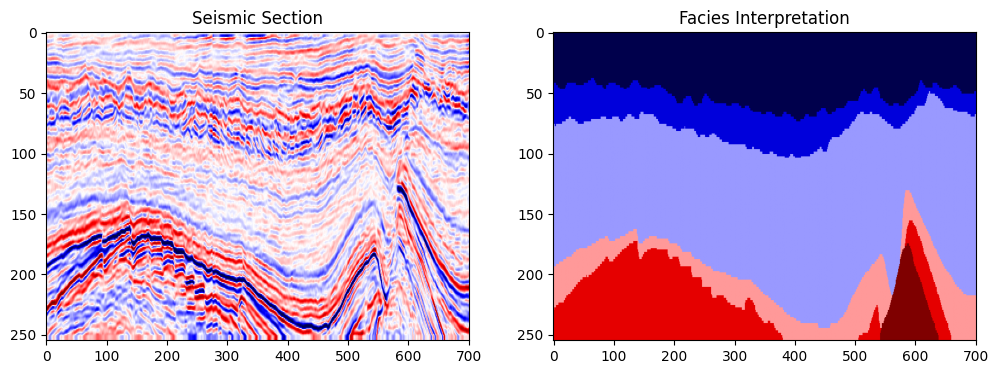

In [ ]:
x, y, d = train_dataset[0]
print(d)
fig = plt.figure(figsize=(12, 4))

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(x.permute(2, 1, 0).numpy(), cmap='seismic', aspect='auto')
ax1.set_title('Seismic Section')

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(y.permute(1, 0).numpy(), cmap='seismic', aspect='auto')
ax2.set_title('Facies Interpretation')

plt.show()

In [34]:
import random
from torch.utils.data import Subset

def split_indices_by_direction(base_dataset, val_frac=0.2, seed=42):
    assert hasattr(base_dataset, "index_map") and base_dataset.index_map is not None, \
        "base_dataset must be created with mode='both'"

    rng = random.Random(seed)

    inline_ids = [i for i, (d, _) in enumerate(base_dataset.index_map) if d == "i"]
    cross_ids  = [i for i, (d, _) in enumerate(base_dataset.index_map) if d == "x"]

    rng.shuffle(inline_ids)
    rng.shuffle(cross_ids)

    n_val_i = int(len(inline_ids) * val_frac)
    n_val_x = int(len(cross_ids)  * val_frac)

    val_indices   = inline_ids[:n_val_i] + cross_ids[:n_val_x]
    train_indices = inline_ids[n_val_i:] + cross_ids[n_val_x:]

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)

    return train_indices, val_indices


In [35]:
train_indices, val_indices = split_indices_by_direction(train_dataset, val_frac=0.2, seed=42)

train_ds = Subset(train_dataset, train_indices)
val_ds   = Subset(train_dataset, val_indices)

torch.Size([1, 701, 255])
torch.Size([701, 255])
i


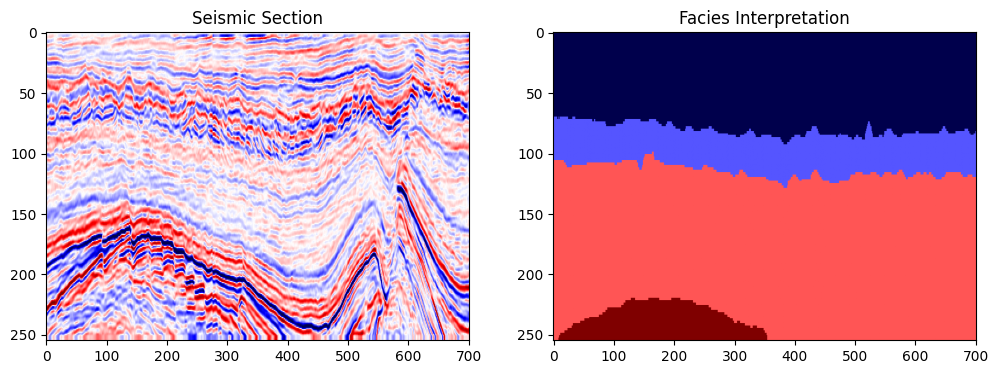

In [ ]:
Nx, y,d = train_ds[0]
print(x.shape)
print(y.shape)
print(d)
fig = plt.figure(figsize=(12, 4))

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(x.permute(2, 1, 0).numpy(), cmap='seismic', aspect='auto')
ax1.set_title('Seismic Section')

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(y.permute(1, 0).numpy(), cmap='seismic', aspect='auto')
ax2.set_title('Facies Interpretation')

plt.show()

In [14]:
from torch.utils.data import Sampler, Subset
import random

class DirectionBatchSampler(Sampler):
    """
    Works with:
      - a base dataset (must have .index_map)
      - a torch.utils.data.Subset of that dataset

    Guarantees each batch is 'i' only or 'x' only.
    """

    def __init__(self, ds_or_subset, batch_size, shuffle=True, seed=42):
        self.ds = ds_or_subset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.rng = random.Random(seed)

        # Detect Subset vs base dataset
        if isinstance(ds_or_subset, Subset):
            self.is_subset = True
            base = ds_or_subset.dataset
            base_indices = list(ds_or_subset.indices)  # indices into base dataset
        else:
            self.is_subset = False
            base = ds_or_subset
            base_indices = list(range(len(ds_or_subset)))  # indices into base dataset (itself)

        if not hasattr(base, "index_map") or base.index_map is None:
            raise ValueError("Base dataset must have index_map (create dataset with mode='both').")

        # Group positions by direction.
        # IMPORTANT:
        # - if Subset: yield positions in subset (0..len(subset)-1)
        # - else: yield base indices directly
        self.inline_ids = []
        self.cross_ids = []

        for pos, base_idx in enumerate(base_indices):
            d, _ = base.index_map[base_idx]
            yield_id = pos if self.is_subset else base_idx

            if d == "i":
                self.inline_ids.append(yield_id)
            else:
                self.cross_ids.append(yield_id)

    def __iter__(self):
        inline = self.inline_ids.copy()
        cross  = self.cross_ids.copy()

        if self.shuffle:
            self.rng.shuffle(inline)
            self.rng.shuffle(cross)

        inline_batches = [inline[i:i+self.batch_size] for i in range(0, len(inline), self.batch_size)]
        cross_batches  = [cross[i:i+self.batch_size]  for i in range(0, len(cross),  self.batch_size)]

        all_batches = inline_batches + cross_batches
        if self.shuffle:
            self.rng.shuffle(all_batches)

        for b in all_batches:
            yield b

    def __len__(self):
        return (len(self.inline_ids) + len(self.cross_ids)) // self.batch_size


In [15]:

batch_size = 12

In [36]:
sampler_train = DirectionBatchSampler(
    train_ds,
    batch_size=batch_size,
    shuffle=True
)

sampler_val = DirectionBatchSampler(
    val_ds,
    batch_size=batch_size,
    shuffle=False
)

train_loader = DataLoader(dataset=train_ds, batch_sampler=sampler_train, num_workers=4)
val_loader   = DataLoader(dataset=val_ds, batch_sampler=sampler_val, num_workers=4)

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 

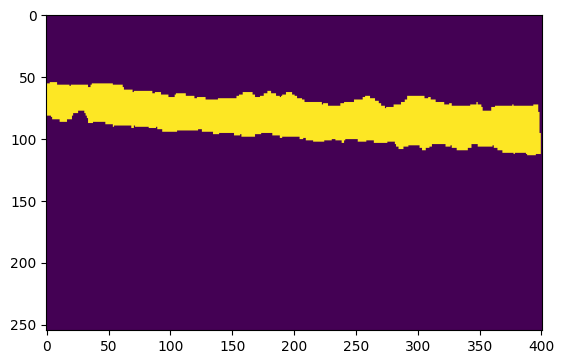

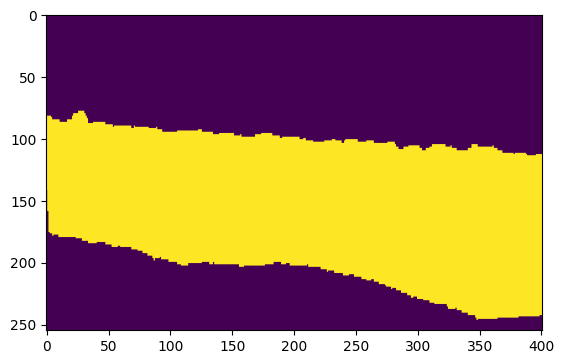

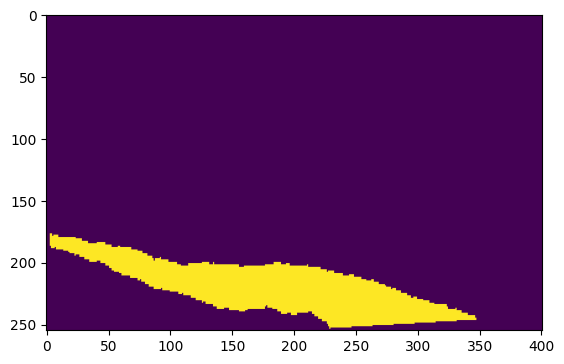

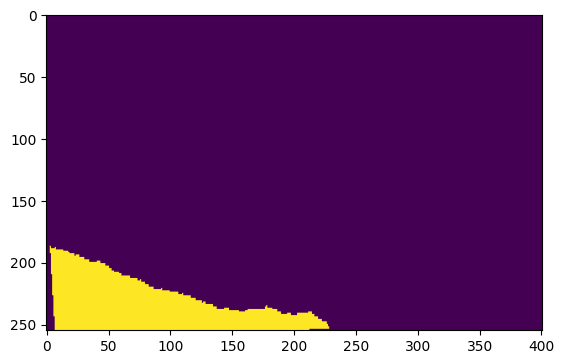

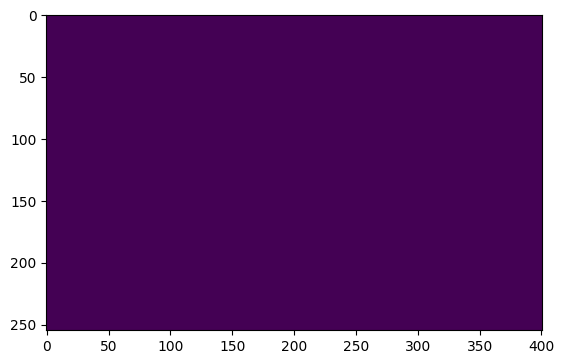

x: torch.Size([12, 1, 401, 255]) torch.float32
y: torch.Size([12, 401, 255]) torch.int64
direction sample: ('x', 'x', 'x', 'x', 'x', 'x', 'x', 'x')


In [ ]:
batch = next(iter(train_loader))

# If your dataset returns (x, y) only:
if len(batch) == 2:
    x, y = batch
    direction = None
# If your dataset returns (x, y, direction):
else:
    x, y, direction = batch
y0 = torch.nn.functional.one_hot(y, num_classes=6).permute(0,3,1,2).float()
print(y0[0])
for channel in range(1,6):
    plt.imshow(y0[0,channel].permute(1, 0))
    plt.show()
print("x:", x.shape, x.dtype)   # expect (B,1,H,W) float32
print("y:", y.shape, y.dtype)   # expect (B,H,W) int64 (long), or (B,1,H,W) if you didn't squeeze in dataset
if direction is not None:
    print("direction sample:", direction[:8])


In [30]:
import torch
import numpy as np
from collections import Counter
from tqdm import tqdm
import builtins


def compute_class_weights(
    dataset,
    num_classes=None,
    ignore_index=-1,
    max_samples=None,
    verbose=True,
):
    """
    Compute class weights from a SeismicSliceDataset.

    Parameters
    ----------
    dataset : torch.utils.data.Dataset
        Your SeismicSliceDataset (single or both mode)
    num_classes : int, optional
        Total number of classes. If None, inferred from data.
    ignore_index : int
        Label value to ignore (e.g. -1 for no-data)
    max_samples : int, optional
        If set, only iterate over first N samples (for speed)
    verbose : bool

    Returns
    -------
    weights : torch.FloatTensor
        Shape (num_classes,), suitable for nn.CrossEntropyLoss
    """

    counter = Counter()
    n = len(dataset) if max_samples is None else builtins.min(len(dataset), max_samples)

    for i in tqdm(range(n), disable=not verbose):
        item = dataset[i]

        # handle (x, y) or (x, y, direction)
        y = item[1]

        y_np = y.numpy().ravel()
        y_np = y_np[y_np != ignore_index]

        counter.update(y_np.tolist())

    if len(counter) == 0:
        raise RuntimeError("No valid labels found to compute class weights.")

    if num_classes is None:
        num_classes = builtins.max(counter.keys()) + 1

    counts = np.zeros(num_classes, dtype=np.float64)
    for cls, cnt in counter.items():
        if cls < num_classes:
            counts[cls] = cnt

    # avoid division by zero
    counts[counts == 0] = 1.0

    # inverse-frequency weighting
    weights = 1.0 / counts

    # normalize (optional but recommended)
    weights = weights / weights.sum() * num_classes

    return torch.tensor(weights, dtype=torch.float32)


In [37]:
class_weights = compute_class_weights(
    train_ds,
    ignore_index=-1,
    #max_samples=500,    # optional speed-up
)

100%|██████████| 882/882 [00:11<00:00, 76.31it/s]


In [ ]:
class_weights

tensor([0.1496, 0.3735, 0.0922, 0.6990, 1.4973, 3.1883])

# U-Net Implementation

In [32]:
import torch.nn as nn

import torch.nn.functional as F

def pad_to_match(src, ref):
    """
    Pad src symmetrically so src H,W == ref H,W.
    src, ref: (B,C,H,W)
    """
    _, _, Hs, Ws = src.shape
    _, _, Hr, Wr = ref.shape

    dh = Hr - Hs
    dw = Wr - Ws

    # Only pad if src is smaller; if src is bigger, you still need crop or you can pad ref instead.
    pad_top = max(0, dh // 2)
    pad_bottom = max(0, dh - dh // 2)
    pad_left = max(0, dw // 2)
    pad_right = max(0, dw - dw // 2)

    return F.pad(src, (pad_left, pad_right, pad_top, pad_bottom))

class ConvBlock(nn.Module):
  def __init__(self, input_channel, output_channel):
    super().__init__()
    self.c = nn.Conv2d(in_channels=input_channel, out_channels=output_channel, kernel_size=3, padding=1)
    self.bn = nn.BatchNorm2d(output_channel)
    self.activation = nn.SiLU()

  def forward(self, x):
    x = self.c(x)
    x = self.bn(x)
    x = self.activation(x)
    return x

class DecBlock(nn.Module):
  def __init__(self, input_channel, output_channel):
    super().__init__()
    self.up = nn.ConvTranspose2d(input_channel, output_channel, kernel_size=2, stride=2, padding=0)
    self.conv_block1 = ConvBlock(output_channel * 2, output_channel) # 2 times for handling skip connection, double the channel size since we concat on the channel dim
    self.conv_block2 = ConvBlock(output_channel, output_channel)

  def forward(self, x, s):
    h = self.up(x)

    if h.shape[-2:] != s.shape[-2:]:
        h, s = pad_to_match(h, s)
    h = torch.cat([h, s], axis=1)
    h = self.conv_block1(h)
    h = self.conv_block2(h)
    return h

class EncBlock(nn.Module):
  def __init__(self, input_channel, output_channel):
    super().__init__()
    self.conv_block1 = ConvBlock(input_channel, output_channel)
    self.conv_block2 = ConvBlock(output_channel, output_channel)
    self.pool = nn.MaxPool2d((2, 2))

  def forward(self, x):
    h = self.conv_block1(x)
    h = self.conv_block2(h)
    p = self.pool(h)
    return h, p


In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels = 1, n_classes = 6):
      super().__init__()
      self.e1 = EncBlock(in_channels, 8)
      self.e2 = EncBlock(8, 16)
      self.e3 = EncBlock(16, 32)
      self.e4 = EncBlock(32, 64)
      self.b1 = ConvBlock(64, 128)
      self.d1 = DecBlock(128, 64)
      self.d2 = DecBlock(64, 32)
      self.d3 = DecBlock(32, 16)
      self.d4 = DecBlock(16, 8)
      self.output = nn.Conv2d(8, n_classes, kernel_size=1, padding=0) # we keep the size, just reduce the channels

    def forward(self, x):
      B, C, H, W = x.shape
      #print(B, C, H, W)
      # --- auto pad to multiples of 16 ---
      pad_h = (16 - H % 16) % 16
      pad_w = (16 - W % 16) % 16

      x = F.pad(x, (0, pad_w, 0, pad_h))  # (left,right,top,bottom)

      s1, x = self.e1(x)
      s2, x = self.e2(x)
      s3, x = self.e3(x)
      s4, x = self.e4(x)
      x = self.b1(x)
      x = self.d1(x, s4)
      x = self.d2(x, s3)
      x = self.d3(x, s2)
      x = self.d4(x, s1)
      output = self.output(x)
      output = output[:, :, :H, :W]
      # print(output.shape)
      return output

In [ ]:
unet = UNet(in_channels=1, n_classes=6).to(device)
unet

UNet(
  (e1): EncBlock(
    (conv_block1): ConvBlock(
      (c): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): SiLU()
    )
    (conv_block2): ConvBlock(
      (c): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): SiLU()
    )
    (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (e2): EncBlock(
    (conv_block1): ConvBlock(
      (c): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): SiLU()
    )
    (conv_block2): ConvBlock(
      (c): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=T

In [ ]:
summary(unet, (1, 701, 255))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 704, 256]              80
       BatchNorm2d-2          [-1, 8, 704, 256]              16
              SiLU-3          [-1, 8, 704, 256]               0
         ConvBlock-4          [-1, 8, 704, 256]               0
            Conv2d-5          [-1, 8, 704, 256]             584
       BatchNorm2d-6          [-1, 8, 704, 256]              16
              SiLU-7          [-1, 8, 704, 256]               0
         ConvBlock-8          [-1, 8, 704, 256]               0
         MaxPool2d-9          [-1, 8, 352, 128]               0
         EncBlock-10  [[-1, 8, 704, 256], [-1, 8, 352, 128]]               0
           Conv2d-11         [-1, 16, 352, 128]           1,168
      BatchNorm2d-12         [-1, 16, 352, 128]              32
             SiLU-13         [-1, 16, 352, 128]               0
        ConvBlock-14      

In [ ]:
summary(unet, (1, 200, 255))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 208, 256]              80
       BatchNorm2d-2          [-1, 8, 208, 256]              16
              SiLU-3          [-1, 8, 208, 256]               0
         ConvBlock-4          [-1, 8, 208, 256]               0
            Conv2d-5          [-1, 8, 208, 256]             584
       BatchNorm2d-6          [-1, 8, 208, 256]              16
              SiLU-7          [-1, 8, 208, 256]               0
         ConvBlock-8          [-1, 8, 208, 256]               0
         MaxPool2d-9          [-1, 8, 104, 128]               0
         EncBlock-10  [[-1, 8, 208, 256], [-1, 8, 104, 128]]               0
           Conv2d-11         [-1, 16, 104, 128]           1,168
      BatchNorm2d-12         [-1, 16, 104, 128]              32
             SiLU-13         [-1, 16, 104, 128]               0
        ConvBlock-14      

In [ ]:
def train(model, optimizer, criterion, data_loader):
    model.train()
    train_loss = 0.
    for x, y, _ in data_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        train_loss += loss*x.size(0)
        optimizer.step()
    train_loss = train_loss / len(data_loader.dataset)
    return train_loss


def valid(model, criterion, data_loader):
    model.eval()
    valid_loss = 0.
    with torch.no_grad():
        for x, y, _ in data_loader:
          x, y = x.to(device), y.to(device)
          logits = model(x)
          loss = criterion(logits, y)
          valid_loss += loss*x.size(0)
        valid_loss = valid_loss / len(data_loader.dataset)
        return valid_loss


In [ ]:
lr = 5e-4
nepochs = 20
wd = 5e-4
class_weights = torch.tensor(
            [0.7151, 0.8811, 0.5156, 0.9346, 0.9683, 0.9852], device=device)

In [ ]:
optimiser = torch.optim.AdamW(params=unet.parameters(), lr=lr, weight_decay=wd)
mseloss = nn.CrossEntropyLoss(weight=class_weights)

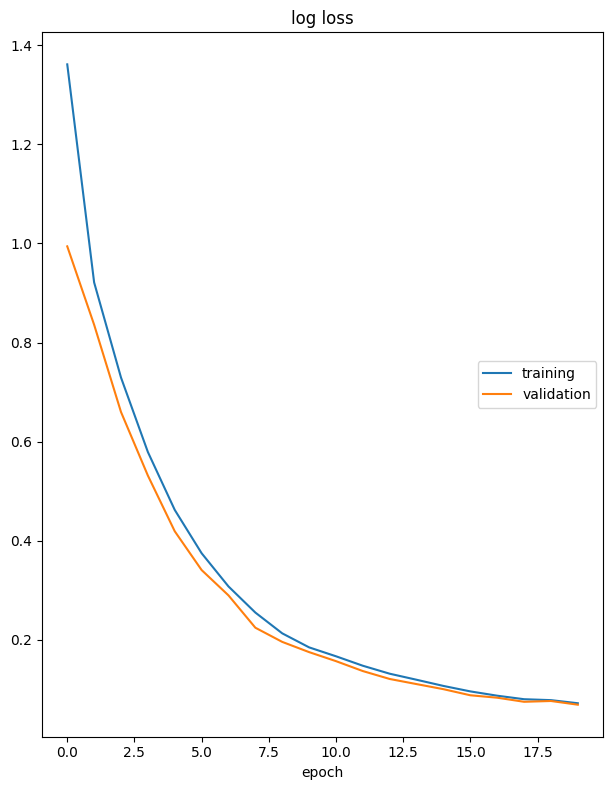

100%|██████████| 20/20 [02:38<00:00,  7.91s/it]

log loss
	training         	 (min:    0.072, max:    1.361, cur:    0.072)
	validation       	 (min:    0.069, max:    0.994, cur:    0.069)


In [ ]:
from tqdm import tqdm

liveloss = PlotLosses()
for i in tqdm(range(nepochs)):
    train_loss = train(unet, optimiser, mseloss, train_loader)
    valid_loss = valid(unet, mseloss, val_loader)

    # Liveloss plot
    logs = {}
    logs['' + 'log loss'] = train_loss.item()
    logs['val_' + 'log loss'] = valid_loss.item()
    liveloss.update(logs)
    liveloss.draw()

In [ ]:
model_save_name = 'unet_seis_class_fix.pt'           # .pt and .pth are common file extensions for saving models in pytorch
path = f"/content/drive/MyDrive/models/{model_save_name}" # use this to store in your Google Drive storage
# path = f'./{model_save_name}'                               # use this to store locally (it will be erased once the colab session is over)
torch.save(unet.state_dict(), path)

In [ ]:
unet.load_state_dict(torch.load(path, map_location=device))

<All keys matched successfully>

In [22]:
import torch.nn as nn

import torch.nn.functional as F

def pad_to_match(src, ref):
    """
    Make src match ref spatially by center-cropping if too big, or symmetric padding if too small.
    src, ref: (B,C,H,W)
    """
    _, _, Hs, Ws = src.shape
    _, _, Hr, Wr = ref.shape

    # center-crop if src is bigger
    if Hs > Hr:
        top = (Hs - Hr) // 2
        src = src[:, :, top:top + Hr, :]
    if Ws > Wr:
        left = (Ws - Wr) // 2
        src = src[:, :, :, left:left + Wr]

    # symmetric pad if src is smaller
    _, _, Hs, Ws = src.shape
    dh, dw = Hr - Hs, Wr - Ws
    if dh > 0 or dw > 0:
        pad_top = dh // 2
        pad_bottom = dh - pad_top
        pad_left = dw // 2
        pad_right = dw - pad_left
        src = F.pad(src, (pad_left, pad_right, pad_top, pad_bottom))
    return src

class ConvBlock(nn.Module):
  def __init__(self, input_channel, output_channel):
    super().__init__()
    self.c = nn.Conv2d(in_channels=input_channel, out_channels=output_channel, kernel_size=3, padding=1)
    self.bn = nn.GroupNorm(8, output_channel)
    self.activation = nn.SiLU()

  def forward(self, x):
    x = self.c(x)
    x = self.bn(x)
    x = self.activation(x)
    return x

class DecBlock(nn.Module):
  def __init__(self, input_channel, output_channel):
    super().__init__()
    self.up = nn.ConvTranspose2d(input_channel, output_channel, kernel_size=2, stride=2, padding=0)
    self.conv_block1 = ConvBlock(output_channel * 2, output_channel) # 2 times for handling skip connection, double the channel size since we concat on the channel dim
    self.conv_block2 = ConvBlock(output_channel, output_channel)

  def forward(self, x, s):
    h = self.up(x)

    if h.shape[-2:] != s.shape[-2:]:
        h = pad_to_match(h, s)
    h = torch.cat([h, s], dim=1)
    h = self.conv_block1(h)
    h = self.conv_block2(h)
    return h

class EncBlock(nn.Module):
  def __init__(self, input_channel, output_channel):
    super().__init__()
    self.conv_block1 = ConvBlock(input_channel, output_channel)
    self.conv_block2 = ConvBlock(output_channel, output_channel)
    self.pool = nn.MaxPool2d((2, 2))

  def forward(self, x):
    h = self.conv_block1(x)
    h = self.conv_block2(h)
    p = self.pool(h)
    return h, p


In [23]:
class UNet(nn.Module):
    def __init__(self, in_channels = 1, n_classes = 6):
      super().__init__()
      self.e1 = EncBlock(in_channels, 8)
      self.e2 = EncBlock(8, 16)
      self.e3 = EncBlock(16, 32)
      self.e4 = EncBlock(32, 64)
      self.e5 = EncBlock(64, 128)
      self.b1 = nn.Sequential(
          ConvBlock(128, 256),
          nn.Dropout2d(p=0.2)
          )
      self.d1 = DecBlock(256, 128)
      self.d2 = DecBlock(128, 64)
      self.d3 = DecBlock(64, 32)
      self.d4 = DecBlock(32, 16)
      self.d5 = DecBlock(16, 8)

      self.output = nn.Conv2d(8, n_classes, kernel_size=1, padding=0) # we keep the size, just reduce the channels

    def forward(self, x):
      B, C, H, W = x.shape
      #print(B, C, H, W)
      # --- auto pad to multiples of 16 ---
      pad_h = (32 - H % 32) % 32
      pad_w = (32 - W % 32) % 32

      x = F.pad(x, (0, pad_w, 0, pad_h))  # (left,right,top,bottom)

      s1, x = self.e1(x)
      s2, x = self.e2(x)
      s3, x = self.e3(x)
      s4, x = self.e4(x)
      s5, x = self.e5(x)
      x = self.b1(x)
      x = self.d1(x, s5)
      x = self.d2(x, s4)
      x = self.d3(x, s3)
      x = self.d4(x, s2)
      x = self.d5(x, s1)
      output = self.output(x)
      output = output[:, :, :H, :W]
      # print(output.shape)
      return output

In [29]:
def dice_loss_weighted(logits, target, class_w=None, eps=1e-6):
    # logits -> probs
    probs = torch.softmax(logits, dim=1)                       # (B,C,H,W)
    C = probs.shape[1]
    target_1h = torch.nn.functional.one_hot(target, C).permute(0,3,1,2).float()

    dims = (0, 2, 3)
    inter = (probs * target_1h).sum(dims)
    denom = probs.sum(dims) + target_1h.sum(dims)

    dice_per_class = (2 * inter + eps) / (denom + eps)         # (C,)
    loss_per_class = 1 - dice_per_class

    if class_w is not None:
        class_w = class_w.to(logits.device).float()
        class_w = class_w / (class_w.mean() + 1e-12)
        class_w = torch.clamp(class_w, 0.7, 2.0)
        return (class_w * loss_per_class).sum() / class_w.sum()

    return loss_per_class.mean()

def focal_loss_from_logits(logits, target, gamma=2.0, alpha=None):
    # logits: (B,C,H,W), target: (B,H,W)
    logp = torch.nn.functional.log_softmax(logits, dim=1)  # (B,C,H,W)
    p = torch.exp(logp)
    # pick p_t for true classes
    target = target.unsqueeze(1)  # (B,1,H,W)
    logp_t = torch.gather(logp, 1, target).squeeze(1)  # (B,H,W)
    p_t = torch.gather(p, 1, target).squeeze(1)        # (B,H,W)

    loss = -((1 - p_t) ** gamma) * logp_t  # (B,H,W)

    if alpha is not None:
        # alpha: (C,) tensor of class weights
        a_t = alpha[target.squeeze(1)]     # (B,H,W)
        loss = a_t * loss

    return loss.mean()

In [ ]:
v1 = 0.3
v2 = 2.0

In [51]:
def train(model, optimizer, criterion, data_loader):
    model.train()
    train_loss = 0.
    for x, y, _ in data_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y) + v1 * dice_loss_weighted(logits, y)# + v2 * focal_loss_from_logits(logits, y)#, alpha=class_weights.to(device))
        loss.backward()
        train_loss += loss*x.size(0)
        optimizer.step()
    train_loss = train_loss / len(data_loader.dataset)
    return train_loss


def valid(model, criterion, data_loader):
    model.eval()
    valid_loss = 0.
    with torch.no_grad():
        for x, y, _ in data_loader:
          x, y = x.to(device), y.to(device)
          logits = model(x)
          loss = criterion(logits, y) + v1 * dice_loss_weighted(logits, y)# + v2 * focal_loss_from_logits(logits, y)#, alpha=class_weights.to(device))
          valid_loss += loss*x.size(0)
        valid_loss = valid_loss / len(data_loader.dataset)
        return valid_loss


In [ ]:
unet = UNet(in_channels=1, n_classes=6).to(device)
unet

In [ ]:
w = class_weights / class_weights.mean()
w = torch.clamp(w, 0.7, 2.0)
class_weights, w

(tensor([0.1505, 0.3755, 0.0927, 0.7024, 1.5096, 3.1693]),
 tensor([0.7000, 0.7000, 0.7000, 0.7024, 1.5096, 2.0000]))

In [ ]:
lr = 5e-4
nepochs = 30
wd = 5e-4
optimiser = torch.optim.AdamW(params=unet.parameters(), lr=lr, weight_decay=wd)
loss = nn.CrossEntropyLoss(weight=class_weights.to(device))

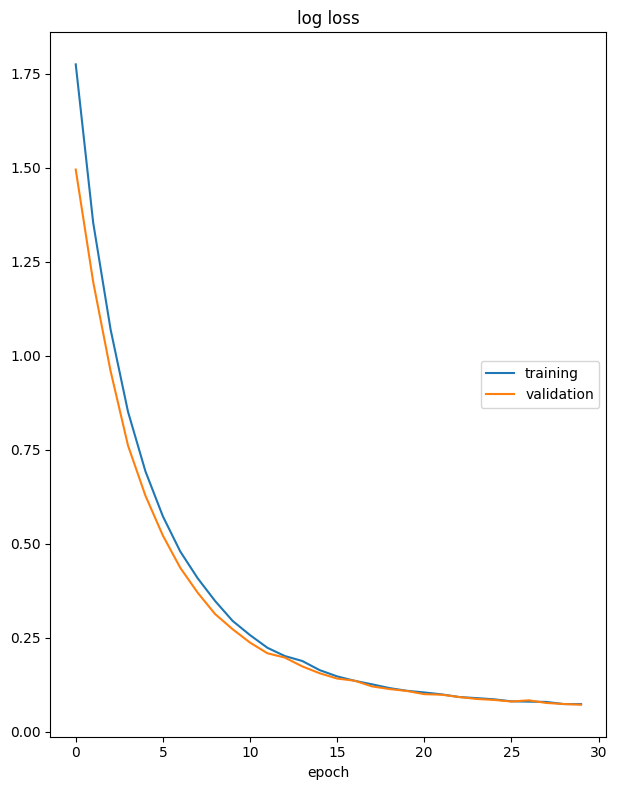

100%|██████████| 30/30 [02:17<00:00,  4.59s/it]

log loss
	training         	 (min:    0.073, max:    1.775, cur:    0.073)
	validation       	 (min:    0.072, max:    1.495, cur:    0.072)


In [ ]:
from tqdm import tqdm

liveloss = PlotLosses()
for i in tqdm(range(nepochs)):
    train_loss = train(unet, optimiser, loss, train_loader)
    valid_loss = valid(unet, loss, val_loader)

    # Liveloss plot
    logs = {}
    logs['' + 'log loss'] = train_loss.item()
    logs['val_' + 'log loss'] = valid_loss.item()
    liveloss.update(logs)
    liveloss.draw()

In [ ]:
model_save_name = 'unet_new_seis_class_256_dice0.3fix.pt'           # .pt and .pth are common file extensions for saving models in pytorch
path = f"/content/drive/MyDrive/models/{model_save_name}" # use this to store in your Google Drive storage
# path = f'./{model_save_name}'                               # use this to store locally (it will be erased once the colab session is over)
#torch.save(unet.state_dict(), path)

In [ ]:
unet.load_state_dict(torch.load(path, map_location=device))

<All keys matched successfully>

# Attention U-Net Implementation

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SelfAttention2D(nn.Module):
    """
    Simple self-attention over spatial positions.
    x: (B, C, H, W) -> (B, C, H, W)
    """
    def __init__(self, channels, num_heads=4, dropout=0.0, gn_groups=8):
        super().__init__()
        assert channels % num_heads == 0, "channels must be divisible by num_heads"
        self.norm = nn.GroupNorm(gn_groups, channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.ff = nn.Sequential(
            nn.Linear(channels, channels * 4),
            nn.SiLU(),
            nn.Linear(channels * 4, channels),
        )

    def forward(self, x):
        b, c, h, w = x.shape
        res = x

        x = self.norm(x)
        x = x.view(b, c, h * w).transpose(1, 2)  # (B, N, C)

        attn_out, _ = self.attn(x, x, x, need_weights=False)
        x = x + attn_out
        x = x + self.ff(x)

        x = x.transpose(1, 2).view(b, c, h, w)
        return res + x


In [108]:
class UNetAttn(nn.Module):
    def __init__(self, in_channels=1, n_classes=6):
        super().__init__()
        self.e1 = EncBlock(in_channels, 8)
        self.e2 = EncBlock(8, 16)
        self.e3 = EncBlock(16, 32)
        self.e4 = EncBlock(32, 64)
        self.e5 = EncBlock(64, 128)

        self.b1 = nn.Sequential(
            ConvBlock(128, 256),
            nn.Dropout2d(p=0.2)
        )

        self.d1 = DecBlock(256, 128)
        self.d2 = DecBlock(128, 64)
        self.d3 = DecBlock(64, 32)
        self.d4 = DecBlock(32, 16)
        self.d5 = DecBlock(16, 8)

        self.output = nn.Conv2d(8, n_classes, kernel_size=1)

        # attention modules
        # e5 output has 128 channels; d1 output has 128 channels; bottleneck has 256 channels.
        self.attn_e5 = SelfAttention2D(channels=128, num_heads=8)
        self.attn_bot = SelfAttention2D(channels=256, num_heads=8)
        self.attn_d1 = SelfAttention2D(channels=128, num_heads=8)

    def forward(self, x):
        B, C, H, W = x.shape

        pad_h = (32 - H % 32) % 32
        pad_w = (32 - W % 32) % 32
        x = F.pad(x, (0, pad_w, 0, pad_h))

        s1, x = self.e1(x)
        s2, x = self.e2(x)
        s3, x = self.e3(x)
        s4, x = self.e4(x)

        s5, x = self.e5(x)

        # ttention on e5 skip
        s5 = self.attn_e5(s5)

        x = self.b1(x)

        # attention at bottleneck
        x = self.attn_bot(x)

        x = self.d1(x, s5)

        # attention after d1
        #x = self.attn_d1(x)

        x = self.d2(x, s4)
        x = self.d3(x, s3)
        x = self.d4(x, s2)
        x = self.d5(x, s1)

        output = self.output(x)
        output = output[:, :, :H, :W]
        return output

In [109]:
unet_attn = UNetAttn(in_channels=1, n_classes=6).to(device)
unet_attn

UNetAttn(
  (e1): EncBlock(
    (conv_block1): ConvBlock(
      (c): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): GroupNorm(8, 8, eps=1e-05, affine=True)
      (activation): SiLU()
    )
    (conv_block2): ConvBlock(
      (c): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): GroupNorm(8, 8, eps=1e-05, affine=True)
      (activation): SiLU()
    )
    (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (e2): EncBlock(
    (conv_block1): ConvBlock(
      (c): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): GroupNorm(8, 16, eps=1e-05, affine=True)
      (activation): SiLU()
    )
    (conv_block2): ConvBlock(
      (c): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): GroupNorm(8, 16, eps=1e-05, affine=True)
      (activation): SiLU()
    )
    (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mod

In [110]:
class_weights

tensor([0.1502, 0.3745, 0.0924, 0.7003, 1.4943, 3.1883])

In [111]:
lr = 5e-4
nepochs = 30
wd = 5e-4
v1 = 0.3
optimiser = torch.optim.Adam(params=unet_attn.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(weight=class_weights.to(device))

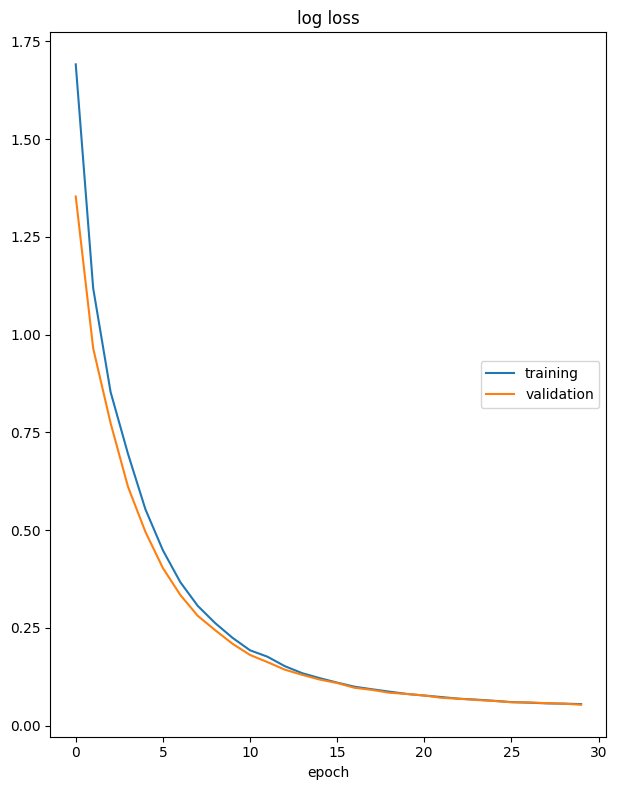

100%|██████████| 30/30 [03:33<00:00,  7.12s/it]

log loss
	training         	 (min:    0.055, max:    1.691, cur:    0.055)
	validation       	 (min:    0.054, max:    1.353, cur:    0.054)


In [112]:
from tqdm import tqdm

liveloss = PlotLosses()
for i in tqdm(range(nepochs)):
    train_loss = train(unet_attn, optimiser, loss, train_loader)
    valid_loss = valid(unet_attn, loss, val_loader)

    # Liveloss plot
    logs = {}
    logs['' + 'log loss'] = train_loss.item()
    logs['val_' + 'log loss'] = valid_loss.item()
    liveloss.update(logs)
    liveloss.draw()

In [115]:
model_save_name = 'unet_new_seis_class_256_dice0.3_attnfix.pt'           # .pt and .pth are common file extensions for saving models in pytorch
path = f"/content/drive/MyDrive/models/{model_save_name}" # use this to store in your Google Drive storage
# path = f'./{model_save_name}'                               # use this to store locally (it will be erased once the colab session is over)
#torch.save(unet_attn.state_dict(), path)

In [116]:
unet_attn.load_state_dict(torch.load(path, map_location=device))

<All keys matched successfully>

# Performance Metrics U-Net

In [50]:
# get the test dataset and labels
test_dataset = SeismicSliceDataset(seismic_path='data/test_once/test1_seismic.npy', labels_path='data/test_once/test1_labels.npy', mode="both")

test_sampler = DirectionBatchSampler(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader   = DataLoader(dataset=test_dataset, batch_sampler=test_sampler, num_workers=2)

In [ ]:
len(test_loader)

In [51]:
import builtins
import torch
import matplotlib.pyplot as plt
from itertools import islice

def plot_segmentation_batch(
    model,
    data_loader,
    device,
    batch_idx=0,
    n_classes=6,
    n_samples=4,
    cmap_seis="seismic",
    cmap_label="tab20",
    show_confidence=True,
    vmax_seis=None
):
    model.eval()

    # get the batch at batch_idx
    try:
        batch = next(islice(iter(data_loader), batch_idx, None))
    except StopIteration:
        raise ValueError(f"batch_idx={batch_idx} out of range for data_loader")

    if len(batch) == 2:
        X, y = batch
        direction = None
    else:
        X, y, direction = batch

    if y.ndim == 4:
        y = y.squeeze(1)

    with torch.no_grad():
        logits = model(X.to(device)).cpu()
        pred = torch.argmax(logits, dim=1)

        if show_confidence:
            probs = torch.softmax(logits, dim=1)
            conf = probs.max(dim=1).values

    B = X.shape[0]
    n = builtins.min(int(n_samples), int(B))
    ncols = 4 if show_confidence else 3

    fig, axes = plt.subplots(n, ncols, figsize=(4*ncols, 3*n))
    if n == 1:
        axes = [axes]

    for i in range(n):
        x_i = X[i, 0]
        y_i = y[i]
        p_i = pred[i]

        dir_str = "" if direction is None else f"{direction[i]}"
        dir_str = " Inline" if dir_str == "i" else " Cross Line" if dir_str == "x" else dir_str

        ax = axes[i][0]
        im0 = ax.imshow(x_i.permute(1, 0), cmap=cmap_seis, aspect="auto", vmax=vmax_seis)
        ax.set_title(f"Seismic{dir_str}")
        ax.axis("off")
        plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[i][1]
        im1 = ax.imshow(y_i.permute(1, 0), cmap=cmap_label, aspect="auto",
                         vmin=0, vmax=n_classes-1)
        ax.set_title(f"Ground Truth{dir_str}")
        ax.axis("off")
        plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[i][2]
        im2 = ax.imshow(p_i.permute(1, 0), cmap=cmap_label, aspect="auto",
                         vmin=0, vmax=n_classes-1)
        ax.set_title(f"Prediction{dir_str}")
        ax.axis("off")
        plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

        if show_confidence:
            ax = axes[i][3]
            im3 = ax.imshow(conf[i].permute(1, 0), aspect="auto")
            ax.set_title(f"Confidence{dir_str}")
            ax.axis("off")
            plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


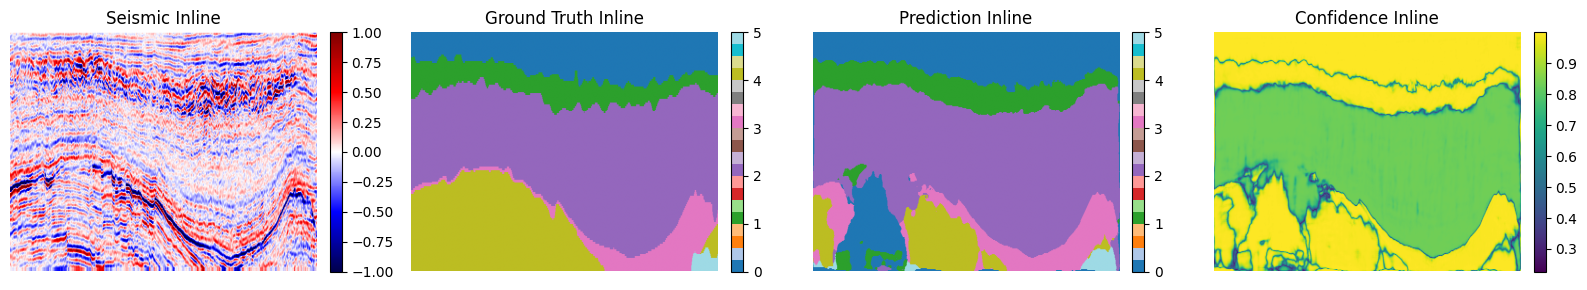

In [120]:
plot_segmentation_batch(
    model=unet_attn,
    data_loader=test_loader,
    device=device,
    batch_idx=0,
    n_samples=1
)


In [121]:
import numpy as np
import torch

def evaluate_metrics_streaming(model, data_loader, device, n_classes=6):
    model.eval()
    hist = np.zeros((n_classes, n_classes), dtype=np.float64)

    def fast_hist(label_true, label_pred, n_class):
        mask = (label_true >= 0) & (label_true < n_class)
        return np.bincount(
            n_class * label_true[mask] + label_pred[mask],
            minlength=n_class**2
        ).reshape(n_class, n_class)

    with torch.no_grad():
        for batch in data_loader:
            X, y = batch[0], batch[1]      # works whether batch has (X,y) or (X,y,dir)
            X = X.to(device)
            y = y.to(device)
            if y.ndim == 4:
                y = y.squeeze(1)

            logits = model(X)
            pred = torch.argmax(logits, dim=1)

            lt = y.detach().cpu().numpy().astype(np.int64)
            lp = pred.detach().cpu().numpy().astype(np.int64)

            for t, p in zip(lt, lp):
                hist += fast_hist(t.flatten(), p.flatten(), n_classes)

    acc = np.diag(hist).sum() / (hist.sum() + 1e-12)
    acc_cls = np.diag(hist) / (hist.sum(axis=1) + 1e-12)
    mean_acc_cls = np.nanmean(acc_cls)
    iu = np.diag(hist) / (hist.sum(axis=1) + hist.sum(axis=0) - np.diag(hist) + 1e-12)
    mean_iu = np.nanmean(iu)
    freq = hist.sum(axis=1) / (hist.sum() + 1e-12)
    fwavacc = (freq[freq > 0] * iu[freq > 0]).sum()

    scores = {
        "Pixel Acc: ": float(acc),
        "Class Accuracy: ": acc_cls,
        "Mean Class Acc: ": float(mean_acc_cls),
        "Freq Weighted IoU: ": float(fwavacc),
        "Mean IoU: ": float(mean_iu),
        "confusion_matrix": hist
    }
    cls_iou = dict(zip(range(n_classes), iu))
    return scores, cls_iou

In [122]:
scores_1, cls_iou_1 = evaluate_metrics_streaming(
    model=unet_attn,
    data_loader=test_loader,
    device=device,
    n_classes=6
)

print(f"Pixel Acc: {scores_1["Pixel Acc: "]}")
print("Class Acc: ")
for i in range(scores_1["Class Accuracy: "].shape[0]):
    print(f"Class {i} Acc: {scores_1["Class Accuracy: "][i]}")
print(f"Mean Class Acc: {scores_1["Mean Class Acc: "]}")
print(f"Freq Weighted IoU: {scores_1["Freq Weighted IoU: "]}")
print(f"Mean IoU: {scores_1["Mean IoU: "]}")
print("Per-class IoU:")
for k, v in cls_iou_1.items():
    print(f"Class {k} IoU: {v}")

Pixel Acc: 0.9005258873877654
Class Acc: 
Class 0 Acc: 0.9687345103680912
Class 1 Acc: 0.9496918660221042
Class 2 Acc: 0.9594654358467107
Class 3 Acc: 0.8939438953712756
Class 4 Acc: 0.6629541963963864
Class 5 Acc: 0.7141089650778505
Mean Class Acc: 0.8581498115137366
Freq Weighted IoU: 0.8251378978606445
Mean IoU: 0.7270633560560396
Per-class IoU:
Class 0 IoU: 0.8879429024003297
Class 1 IoU: 0.7839158158572752
Class 2 IoU: 0.9180602471314747
Class 3 IoU: 0.6433479929456793
Class 4 IoU: 0.6431529602527031
Class 5 IoU: 0.4859602177487752


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, class_names=None, normalize=False):
    """
    cm : ndarray (C,C)
    normalize : if True, normalize rows (GT-wise)
    """

    if normalize:
        cm = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="viridis")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix" + (" (Normalized)" if normalize else ""))

    if class_names is not None:
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticklabels(class_names)

    # write values inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            txt = f"{val:.2f}" if normalize else f"{int(val)}"
            ax.text(j, i, txt, ha="center", va="center",
                    color="white" if val > cm.max()/2 else "black")

    plt.tight_layout()
    plt.show()


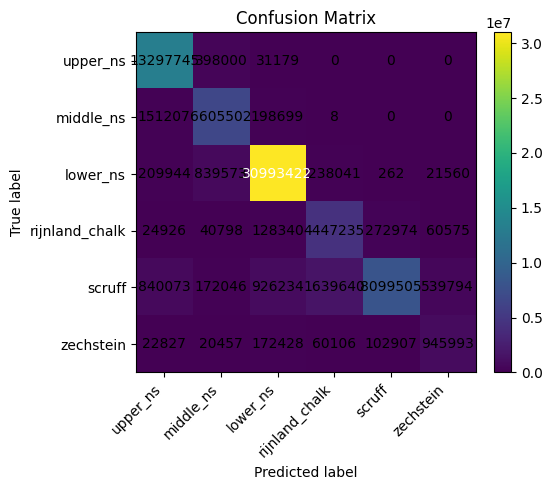

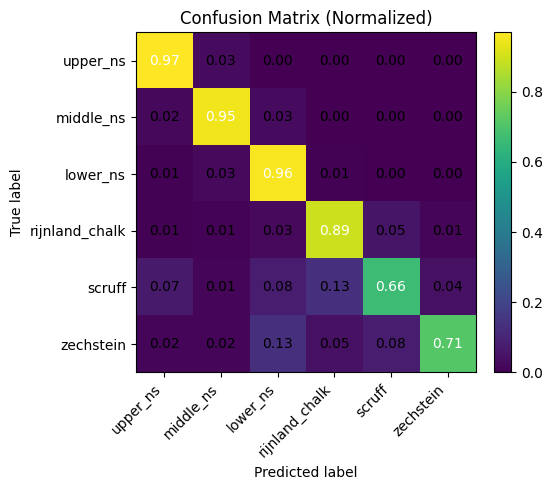

In [98]:
class_names = ['upper_ns', 'middle_ns', 'lower_ns',
                   'rijnland_chalk', 'scruff', 'zechstein']

cm_1 = scores_1["confusion_matrix"]
plot_confusion_matrix(cm_1, class_names=class_names, normalize=False)
plot_confusion_matrix(cm_1, class_names=class_names, normalize=True)

In [ ]:
test_dataset_2 = SeismicSliceDataset(seismic_path='data/test_once/test2_seismic.npy', labels_path='data/test_once/test2_labels.npy', mode="both")
test_sampler_2 = DirectionBatchSampler(
    test_dataset_2,
    batch_size=batch_size,
    shuffle=False
)

test_loader_2   = DataLoader(dataset=test_dataset_2, batch_sampler=test_sampler_2, num_workers=2)

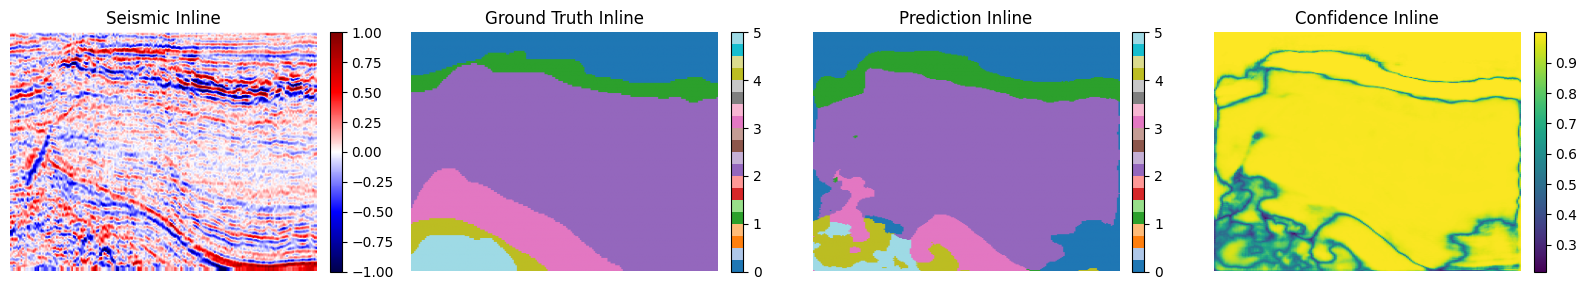

In [ ]:
plot_segmentation_batch(
    model=unet,
    data_loader=test_loader_2,
    device=device,
    batch_idx=0,     # <-- plot 6th batch
    n_samples=1
)


In [ ]:
scores_2, cls_iou_2 = evaluate_metrics_streaming(
    model=unet,
    data_loader=test_loader_2,
    device=device,
    n_classes=6
)

print(f"Pixel Acc: {scores_2["Pixel Acc: "]}")
print("Class Acc: ")
for i in range(scores_2["Class Accuracy: "].shape[0]):
    print(f"Class {i} Acc: {scores_2["Class Accuracy: "][i]}")
print(f"Mean Class Acc: {scores_2["Mean Class Acc: "]}")
print(f"Freq Weighted IoU: {scores_2["Freq Weighted IoU: "]}")
print(f"Mean IoU: {scores_2["Mean IoU: "]}")
print("Per-class IoU:")
for k, v in cls_iou_2.items():
    print(f"Class {k} IoU: {v}")

Pixel Acc: 0.9074410459691364
Class Acc: 
Class 0 Acc: 0.967242319966519
Class 1 Acc: 0.9362217116702924
Class 2 Acc: 0.9294906744694883
Class 3 Acc: 0.5610838780668213
Class 4 Acc: 0.3742960261820115
Class 5 Acc: 0.5958569606534014
Mean Class Acc: 0.7273652618347556
Freq Weighted IoU: 0.8455830125479279
Mean IoU: 0.6020557186254305
Per-class IoU:
Class 0 IoU: 0.8976289772544801
Class 1 IoU: 0.8065550310168688
Class 2 IoU: 0.8946100900653717
Class 3 IoU: 0.4763801434650186
Class 4 IoU: 0.1629891333343582
Class 5 IoU: 0.3741709366164851


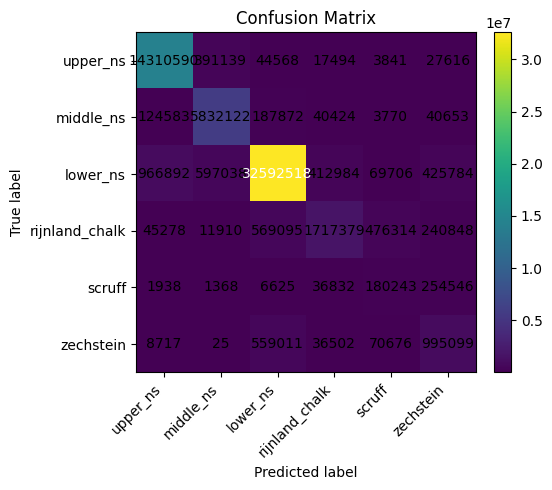

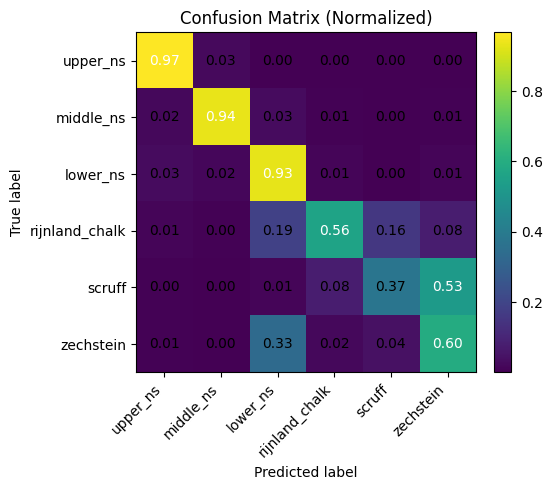

In [ ]:
cm_2 = scores_2["confusion_matrix"]
plot_confusion_matrix(cm_2, class_names=class_names, normalize=False)
plot_confusion_matrix(cm_2, class_names=class_names, normalize=True)

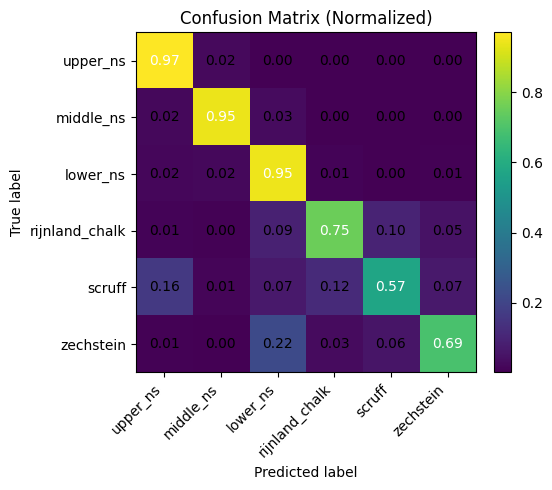

In [ ]:
cm = cm_1 + cm_2
plot_confusion_matrix(cm, class_names=class_names, normalize=True)

In [ ]:
def plot_sample_by_index(model, dataset, device, idx, n_classes=6, title=""):
    model.eval()

    item = dataset[idx]
    if len(item) == 2:
        x, y = item
        direction = None
    else:
        x, y, direction = item

    x = x.unsqueeze(0).to(device)
    if y.ndim == 3:
        y = y.squeeze(0)

    with torch.no_grad():
        logits = model(x).cpu()
        pred = torch.argmax(logits, dim=1)[0]

    fig, axs = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(title)
    axs[0].imshow(x[0,0].cpu().permute(1,0), cmap="seismic", aspect="auto")
    axs[0].set_title("Seismic")
    axs[1].imshow(y.permute(1,0), cmap="tab20", vmin=0, vmax=n_classes-1)
    axs[1].set_title("Ground Truth")
    axs[2].imshow(pred.permute(1,0), cmap="tab20", vmin=0, vmax=n_classes-1)
    axs[2].set_title("Prediction")
    for ax in axs:
        ax.axis("off")
    plt.show()


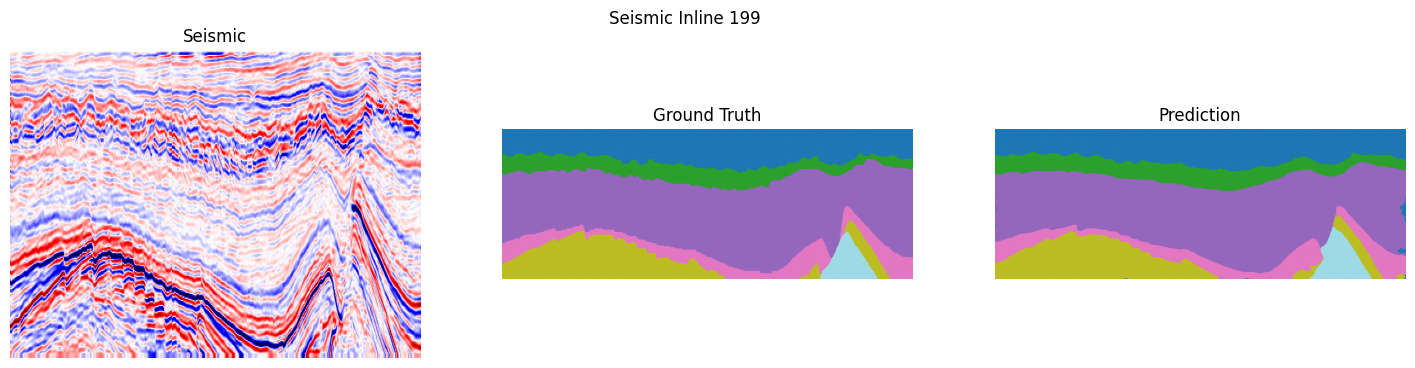

In [ ]:
il_to_plot = 199
tp_to_plot = "Inline"
plot_sample_by_index(unet, test_dataset, device, idx=il_to_plot, title=f"Seismic {tp_to_plot} {il_to_plot}")

In [ ]:
len(test_dataset)

901

In [ ]:
test_dataset[200][0].shape

torch.Size([1, 200, 255])

In [ ]:
print("len:", len(test_dataset))
print("index_map[200]:", test_dataset.index_map[199])

len: 901
index_map[200]: ('i', 199)


In [ ]:
test_dataset.index_map

In [ ]:
train_dataset[0][0].shape

torch.Size([1, 701, 255])

In [ ]:
train_dataset[500][0].shape

torch.Size([1, 401, 255])

# Conditioned Diffusion Model Implementation

In [18]:
dim = 64

T = 1000
t = torch.linspace(1, T, T + 1)
s = 0.0081

y = torch.cos((((t / T) + s) / (1 + s)) * torch.pi / 2) ** 2

alphas_bar = y / y[0]
betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
betas = torch.clip(betas, 1e-8, 0.999)
alphas = 1 -  betas
alphas_bar = torch.cumprod(alphas, axis=0) ## close with alphas_bar[1:]


In [19]:
# define a function to handle the discrepancy between batch vs schedule shapes
def fix_batch(sched, t, device):
    """extract sched at time t, and expand to batch dimensionality"""
    return sched.to(device)[t.to(device)[:,None,None,None]]

# define a function that implements the forward diffusion process
def forward_diffusion(x0, t, e):
    """run the forward diffusion process on x up to time t using noise e"""
    sqrt_alpha_term = fix_batch(torch.sqrt(alphas_bar), t, x0.device) * x0
    one_minus_sqrt_term = fix_batch(torch.sqrt(1 - alphas_bar), t, x0.device) * e
    return sqrt_alpha_term + one_minus_sqrt_term

In [20]:
# define a function that implements the reverse diffusion process
def reverse_diffusion(x, t, e, z):
    """run the reverse diffusion process"""
    sigma = fix_batch(torch.sqrt(betas), t, x.device)
    sqrt_recip_alphas = fix_batch(torch.sqrt(1.0 / alphas), t, x.device)
    scale = fix_batch((1 - alphas) / torch.sqrt(1. - alphas_bar), t, x.device)

    return sqrt_recip_alphas * (x - scale*e) + sigma*z

In [21]:
# define the sinusoidal position embeddings
class SinusoidalPositionEmbeddings(nn.Module):
    """sinusoidal position embedding, https://arxiv.org/abs/1706.03762"""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [22]:
# define a convolutional block with time-embedding
class ConvBlock(nn.Module):
    """time-conditioned convolutional block"""

    def __init__(self, in_c, out_c, embed_dim):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
        self.dense = nn.Linear(embed_dim, out_c)  ## reshapes the time embedding length to the number of channels
        self.bn = nn.GroupNorm(num_groups=8, num_channels=out_c)
        self.act = nn.GELU()

    def forward(self, x, t_embed):
        x = self.conv(x)
        x += self.dense(t_embed)[..., None, None]
        x = self.bn(x)
        x = self.act(x)
        return x

# define an encoder block with time-embedding
class EncBlock(nn.Module):
    """time-conditioned U-Net encoder block"""

    def __init__(self, in_c, out_c, embed_dim):
        super().__init__()
        self.conv_block1 = ConvBlock(in_c, out_c, embed_dim)
        self.conv_block2 = ConvBlock(out_c, out_c, embed_dim)
        self.pool = nn.MaxPool2d((2, 2))

    def forward(self, x, t_embed):
        h = self.conv_block1(x, t_embed)
        h = self.conv_block2(h, t_embed)
        p = self.pool(h)
        #print(h.shape, p.shape)
        return h, p

# define an decoder block with time-embedding
class DecBlock(nn.Module):
    """time-conditioned U-Net decoder block"""

    def __init__(self, in_c, skip_c, out_c, embed_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, padding=0, stride=2)
        self.conv_block1 = ConvBlock(out_c
                                     + skip_c
                                     #+ out_c + out_c
                                     , out_c, embed_dim)
        self.conv_block2 = ConvBlock(out_c, out_c, embed_dim)

    def forward(self, x, s, t_embed):
        h = self.up(x)
        # print(h.shape, s.shape)
        if h.shape[-2:] != s.shape[-2:]:
          h = pad_to_match(h, s)
        h = torch.cat([h, s], axis = 1) # concatenate x with U-Net skip connection from encoder
        #print(h.shape, s.shape)
        h = self.conv_block1(h, t_embed)
        h = self.conv_block2(h, t_embed)
        return h

In [ ]:
class DiffUnet(nn.Module):
    """DDPM U-Net, https://arxiv.org/abs/2006.11239 and https://arxiv.org/abs/1505.04597"""

    def __init__(self, in_channels, out_channels, cond_channels, embed_dim):
        super().__init__()

        # time positional embedding MLP
        self.embed = nn.Sequential(SinusoidalPositionEmbeddings(embed_dim),
                                   nn.Linear(embed_dim, embed_dim),
                                   nn.GELU(),
                                   nn.Linear(embed_dim, embed_dim))

        # encoder
        self.e1 = EncBlock(in_channels + cond_channels, 32, embed_dim)
        self.e2 = EncBlock(32 + 32, 128, embed_dim)
        self.e3 = EncBlock(64 + 128, 256, embed_dim)
        self.e4 = EncBlock(128 + 256, 512, embed_dim)

        # C
        self.c1 = EncBlock(cond_channels, 32, embed_dim)
        self.c2 = EncBlock(32, 64, embed_dim)
        self.c3 = EncBlock(64, 128, embed_dim)
        self.c4 = EncBlock(128, 256, embed_dim)

        # bottleneck
        self.b1 = ConvBlock(512 + 256, 1024, embed_dim)
        self.b2 = ConvBlock(1024, 1024, embed_dim)

        # decoder
        self.d1 = DecBlock(1024, 768, 512, embed_dim)
        self.d2 = DecBlock(512, 384, 256, embed_dim)
        self.d3 = DecBlock(256, 192, 128, embed_dim)
        self.d4 = DecBlock(128, 64, 64, embed_dim)

        # output layer
        self.output_eps = nn.Conv2d(64, out_channels, kernel_size=1, padding=0)
        #self.output_seg = nn.Conv2d(64, out_channels, kernel_size=1, padding=0)

    def forward(self, x, t, cond):
        B, C, H, W = x.shape
        #print(B, C, H, W)
        # --- auto pad to multiples of 16 ---
        pad_h = (16 - H % 16) % 16
        pad_w = (16 - W % 16) % 16

        x = F.pad(x, (0, pad_w, 0, pad_h))  # (left,right,top,bottom)
        cond = F.pad(cond, (0, pad_w, 0, pad_h))
        t_embed = self.embed(t)

        # encoder
        #print(x.shape, cond.shape)
        x = torch.cat([x, cond], dim=1)
        s1, x = self.e1(x, t_embed)
        #print(f"self.e1 = s1 shape: {s1.shape}, x shape: {x.shape}")
        f1, cond = self.c1(cond, t_embed)
        #print(f"self.c1 = f1 shape: {f1.shape}, cond shape: {cond.shape}")
        x = torch.cat([x, cond], dim=1) #add t1 image as conditioning
        #print(f"cat x with cond from c1 = x shape: {x.shape}")
        s1 = torch.cat([s1, f1], dim=1)
        #print(f"cat s1 with f1 from c1 = s1 shape: {s1.shape}")
        s2, x = self.e2(x, t_embed)
        #print(f"self.e2 = s2 shape: {s2.shape}, x shape: {x.shape}")
        f2, cond = self.c2(cond, t_embed)
        #print(f"self.c2 = f2 shape: {f2.shape}, cond shape: {cond.shape}")
        x = torch.cat([x, cond], dim=1)
        #print(f"cat x with cond from c2 = x shape: {x.shape}")
        s2 = torch.cat([s2, f2], dim=1)
        #print(f"cat s2 with f2 from c2 = s2 shape: {s2.shape}")
        # print(x.shape)
        s3, x = self.e3(x, t_embed)
        f3, cond = self.c3(cond, t_embed)
        x = torch.cat([x, cond], dim=1)
        s3 = torch.cat([s3, f3], dim=1)
        s4, x = self.e4(x, t_embed)
        f4, cond = self.c4(cond, t_embed)
        x = torch.cat([x, cond], dim=1)
        s4 = torch.cat([s4, f4], dim=1)

        # bottleneck
        x = self.b1(x, t_embed)
        x = self.b2(x, t_embed)

        # decoder
        x = self.d1(x, s4, t_embed)
        x = self.d2(x, s3, t_embed)
        x = self.d3(x, s2, t_embed)
        #print(x.shape, s1.shape)
        x = self.d4(x, s1, t_embed)

        # output
        output_eps = self.output_eps(x)
        output_eps = output_eps[:, :, :H, :W]
        #output_seg = self.output_seg(x)
        #output_seg = output_seg[:, :, :H, :W]
        return output_eps#, output_seg

In [ ]:
lr = 1e-4
wd = 1e-5
alp = 3
bt = 1

In [ ]:
# define the model and send to the GPU
diff_model = DiffUnet(6, 6, 1, dim * 4).to(device)

# specify the Adam optimizer with a learning rate of 2e-4
diff_opt = torch.optim.AdamW(diff_model.parameters(), lr=lr, weight_decay=wd)

# set the criterion to be the mse loss
diff_criterion = nn.MSELoss()
diff_criterion_seg = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
    )

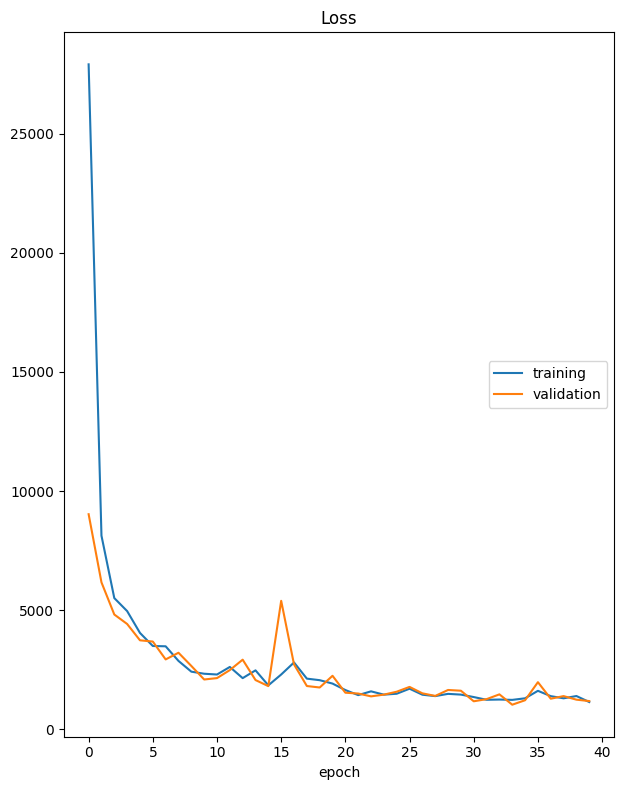

Loss
	training         	 (min: 1148.902, max: 27909.826, cur: 1148.902)
	validation       	 (min: 1036.979, max: 9030.920, cur: 1189.356)


In [ ]:
from tqdm import tqdm

n_epoch = 40

# Set up liveloss plot: put both curves in ONE panel
liveloss = PlotLosses(groups={'loss': ['train_loss', 'val_loss']})

for epoch in range(n_epoch):

    # TRAINING LOOP #
    diff_model.train()
    pbar = tqdm(train_loader)
    train_tot_loss = 0.0

    for X, y, _ in pbar:
        X = X.to(device)
        if y.ndim == 4:
          y_idx = y.squeeze(1).to(device).long()
        else:
          y_idx = y.to(device).long()

        # diffusion "x0" state: (B,1,H,W) float
        y0 = torch.nn.functional.one_hot(y_idx, num_classes=6).permute(0,3,1,2).float()

        # zero the gradients
        diff_opt.zero_grad()

        # sample t from a uniform distribution
        t = torch.randint(0, T, (y0.shape[0], ), dtype=torch.long).to(device)

        # sample e from a normal distribution
        e = torch.randn_like(y0)

        # run the forward diffusion process to add noise to x0
        y_t = forward_diffusion(y0, t, e)

        # calculate the loss between the predicted noise and the true noise
        e_pred = diff_model(y_t, t, X)

        loss_eps = diff_criterion(e_pred, e)

        pred = torch.randn_like(y0)

        for i in reversed(range(0,T)):

          # sample z from a normal distribution if condition met
          if i > 0:
              z = torch.randn_like(pred)
          else:
              z = 0

          # convert t to a tensor, send to the GPU, and expand its first dimension to be equal to batch size
          i = torch.tensor(i).to(device).expand(pred.shape[0])

          # denoise x
          pred = reverse_diffusion(pred, i, e_pred, z)

        # mask when to apply segmentation loss
        mask = (t < T)   # or T//3, tune this

        if mask.any():
            loss_seg = diff_criterion_seg(pred[mask], y_idx[mask]) + bt * dice_loss_weighted(pred[mask], y_idx[mask])
        else:
            loss_seg = 0.0

        loss = loss_eps + alp * loss_seg

        # backpropagation to obtain gradients w.r.t model parameters
        loss.backward()

        # take an optimisation step
        diff_opt.step()

        # Report current loss using tqdm
        train_tot_loss += loss.item()
        pbar.set_description(f"train_loss: {loss.item():.4f}")

    # average training loss for the epoch (float)
    train_loss = train_tot_loss / len(train_loader)

    # VALIDATION LOOP #
    diff_model.eval()
    val_tot_loss = 0.0

    with torch.no_grad():
        val_pbar = tqdm(val_loader)
        for X, y, _ in val_pbar:
            X = X.to(device)
            if y.ndim == 4:
              y_idx = y.squeeze(1).to(device).long()
            else:
              y_idx = y.to(device).long()

            y0 = torch.nn.functional.one_hot(y_idx, num_classes=6).permute(0,3,1,2).float()

            # sample t from a uniform distribution
            t = torch.randint(0, T, (y0.shape[0], ), dtype=torch.long).to(device)

            # sample e from a normal distribution
            e = torch.randn_like(y0)

            # forward diffusion
            y_t = forward_diffusion(y0, t, e)

            # predict noise
            e_pred = diff_model(y_t, t, X)

            loss_eps = diff_criterion(e_pred, e)

            pred = torch.randn_like(y0)

            for i in reversed(range(0,T)):

              # sample z from a normal distribution if condition met
              if i > 0:
                  z = torch.randn_like(pred)
              else:
                  z = 0

              # convert t to a tensor, send to the GPU, and expand its first dimension to be equal to batch size
              i = torch.tensor(i).to(device).expand(pred.shape[0])

              # denoise x
              pred = reverse_diffusion(pred, i, e_pred, z)

            # mask when to apply segmetnation loss
            mask = (t < T)   # or T//3, tune this

            if mask.any():
                loss_seg = diff_criterion_seg(pred[mask], y_idx[mask]) + bt * dice_loss_weighted(pred[mask], y_idx[mask])
            else:
                loss_seg = 0.0

            val_loss_batch = loss_eps + alp * loss_seg

            val_tot_loss += val_loss_batch.item()
            val_pbar.set_description(f"val_loss: {val_loss_batch.item():.4f}")

    # average validation loss for the epoch (float)
    val_loss = val_tot_loss / len(val_loader)

    logs = {
        'train_loss': float(train_loss),
        'val_loss': float(val_loss),
    }
    liveloss.update(logs)
    liveloss.draw()

In [ ]:
model_save_name = 'diff_model_seis_class_FIX.pt'           # .pt and .pth are common file extensions for saving models in pytorch
path = f"/content/drive/MyDrive/models/{model_save_name}" # use this to store in your Google Drive storage
# path = f'./{model_save_name}'                               # use this to store locally (it will be erased once the colab session is over)
torch.save(diff_model.state_dict(), path)

In [ ]:
diff_model.load_state_dict(torch.load(path, map_location=device))

In [ ]:
class_weights

tensor([0.1496, 0.3735, 0.0922, 0.6990, 1.4973, 3.1883])

In [48]:
from torchvision.utils import make_grid

def plot_batch(batch, nrow=8, title="", ax=None):
    """
    Plots MRI slices in a grid with correct per-image contrast,
    matching individual imshow behavior.
    """
    #print("---", batch.shape)
    batch = batch.detach().cpu()
    #print(batch)
    # Ensure shape = (B, 1, H, W)
    if batch.ndim == 3:   # (B, H, W)
        batch = batch.unsqueeze(1)
    elif batch.ndim != 4 or batch.size(1) != 1:
        batch = torch.argmax(batch, dim=1)
        batch = batch.unsqueeze(1)

    imgs = []
    for img in batch:  # img: (1, H, W)
        x = img[0].permute(1, 0)     # (H, W)

        imgs.append(x.unsqueeze(0))  # back to (1,H,W)

    batch_disp = torch.stack(imgs, dim=0)  # (B,1,H,W)

    # Make grid
    grid = make_grid(batch_disp, nrow=nrow)[0]  # (H,W)

    # Plot
    if ax is None:
        ncol = (batch_disp.size(0) + nrow - 1) // nrow
        _, ax = plt.subplots(figsize=(2*nrow, 2*ncol))

    im = ax.imshow(grid, cmap="seismic")
    ax.axis("off")
    # show the colorbar
    plt.colorbar(im, ax = ax)

    if title:
        ax.set_title(title)

In [ ]:
# ensure model is in evaluation mode
diff_model.eval()

# randomly sample an xT batch from a normal distribution

X, y, _ = next(iter(test_loader))

cond = X.to(device)[:1]

y = y.to(device)[:1]
# print(cond.shape, y.shape)
y_onehot = F.one_hot(y, num_classes=6)      # (B,H,W,C)
y_onehot = y_onehot.permute(0,3,1,2).float() # (B,C,H,W)

x = torch.randn_like(y_onehot)

# send to the GPU
x = x.to(device)

# context management to ensure gradients are not tracked for any torch tensors or parameters
with torch.no_grad():

    # loop over time from T to 0
    for t in reversed(range(0,T)):

        # sample z from a normal distribution if condition met
        if t > 0:
            z = torch.randn_like(x)
        else:
            z = 0

        # visualize samples x every 100 iterations
        if t  == 0:
          x = torch.clamp(x, 0, 1)

          print(f'samples at t={t}')
          plot_batch(x.cpu(), 2, "Pred (argmax x0_hat)")
          plot_batch(y.cpu(), 2, "Ground Truth")

        # convert t to a tensor, send to the GPU, and expand its first dimension to be equal to batch size
        t = torch.tensor(t).to(device).expand(x.shape[0])

        # denoise x
        e = diff_model(x, t, cond)

        x = reverse_diffusion(x, t, e, z)

        # clipping to ensure the sample values remain in the range -1 to 1
        #x = torch.clamp(x, 0, 1)

In [ ]:
import builtins
import torch
import matplotlib.pyplot as plt
from itertools import islice

def plot_segmentation_batch_diff(
    model,
    data_loader,
    device,
    batch_idx=0,          # <-- NEW
    n_classes=6,
    n_samples=4,
    cmap_seis="seismic",
    cmap_label="tab20",
    show_confidence=True,
    vmax_seis=None
):
    model.eval()

    # get the batch at batch_idx
    try:
        batch = next(islice(iter(data_loader), batch_idx, None))
    except StopIteration:
        raise ValueError(f"batch_idx={batch_idx} out of range for data_loader")

    if len(batch) == 2:
        X, y = batch
        direction = None
    else:
        X, y, direction = batch

    if y.ndim == 4:
        y = y.squeeze(1)

    cond = X.to(device)[:1]
    y = y.to(device)[:1]
    y_onehot = F.one_hot(y, num_classes=6)      # (B,H,W,C)
    y_onehot = y_onehot.permute(0,3,1,2).float() # (B,C,H,W)
    x = torch.randn_like(y_onehot)
    x = x.to(device)

    with torch.no_grad():
         # loop over time from T to 0
        for t in reversed(range(0,T)):

            # sample z from a normal distribution if condition met
            if t > 0:
                z = torch.randn_like(x)
            else:
                z = 0

            # convert t to a tensor, send to the GPU, and expand its first dimension to be equal to batch size
            t = torch.tensor(t).to(device).expand(x.shape[0])

            # denoise x
            e = model(x, t, cond)

            x = reverse_diffusion(x, t, e, z)

            x = torch.clamp(x, -1, 1)

        pred = torch.argmax(x, dim=1)

        if show_confidence:
            probs = torch.softmax(x, dim=1)
            conf = probs.max(dim=1).values

    B = X.shape[0]
    n = builtins.min(int(n_samples), int(B))
    ncols = 4 if show_confidence else 3

    fig, axes = plt.subplots(n, ncols, figsize=(4*ncols, 3*n))
    if n == 1:
        axes = [axes]

    for i in range(n):
        x_i = X[i, 0]
        y_i = y[i]
        p_i = pred[i]

        dir_str = "" if direction is None else f"{direction[i]}"
        dir_str = " Inline" if dir_str == "i" else " Cross Line" if dir_str == "x" else dir_str

        ax = axes[i][0]
        im0 = ax.imshow(x_i.detach().cpu().permute(1, 0), cmap=cmap_seis, aspect="auto", vmax=vmax_seis)
        ax.set_title(f"Seismic{dir_str}")
        ax.axis("off")
        plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[i][1]
        im1 = ax.imshow(y_i.detach().cpu().permute(1, 0), cmap=cmap_label, aspect="auto",
                         vmin=0, vmax=n_classes-1)
        ax.set_title(f"Ground Truth{dir_str}")
        ax.axis("off")
        plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[i][2]
        im2 = ax.imshow(p_i.detach().cpu().permute(1, 0), cmap=cmap_label, aspect="auto",
                         vmin=0, vmax=n_classes-1)
        ax.set_title(f"Prediction{dir_str}")
        ax.axis("off")
        plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

        if show_confidence:
            ax = axes[i][3]
            im3 = ax.imshow(conf[i].detach().cpu().permute(1, 0), aspect="auto")
            ax.set_title(f"Confidence{dir_str}")
            ax.axis("off")
            plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


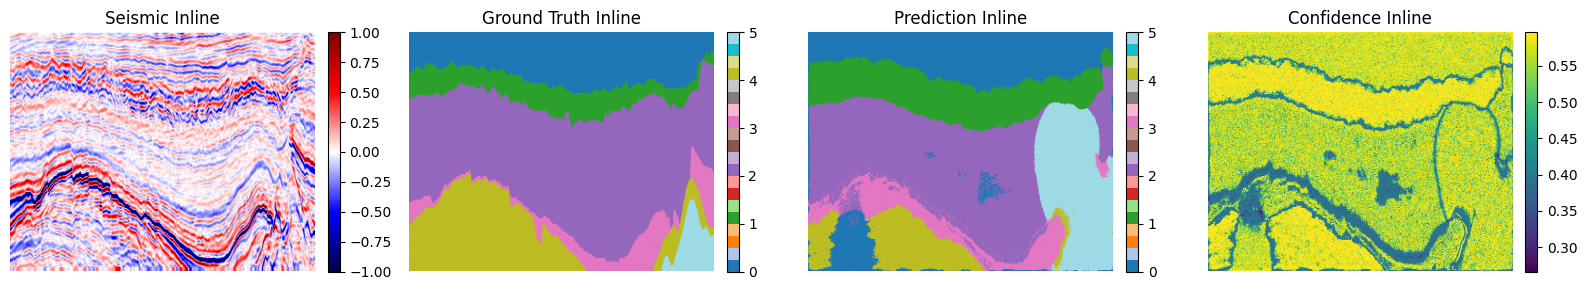

In [ ]:
plot_segmentation_batch_diff(
    model=diff_model,
    data_loader=test_loader,
    device=device,
    batch_idx=10,
    n_samples=1
)

In [ ]:
import numpy as np
import torch

def evaluate_metrics_diff(model, data_loader, device, n_classes=6):
    model.eval()
    hist = np.zeros((n_classes, n_classes), dtype=np.float64)

    def fast_hist(label_true, label_pred, n_class):
        mask = (label_true >= 0) & (label_true < n_class)
        return np.bincount(
            n_class * label_true[mask] + label_pred[mask],
            minlength=n_class**2
        ).reshape(n_class, n_class)

    with torch.no_grad():
        for batch in tqdm(data_loader):
            X, y = batch[0], batch[1]      # works whether batch has (X,y) or (X,y,dir)
            if y.ndim == 4:
                y = y.squeeze(1)
            cond = X.to(device)
            y = y.to(device)
            y_onehot = F.one_hot(y, num_classes=6)      # (B,H,W,C)
            y_onehot = y_onehot.permute(0,3,1,2).float() # (B,C,H,W)
            x = torch.randn_like(y_onehot)
            x = x.to(device)

            for t in reversed(range(0,T)):

              # sample z from a normal distribution if condition met
              if t > 0:
                  z = torch.randn_like(x)
              else:
                  z = 0

              # convert t to a tensor, send to the GPU, and expand its first dimension to be equal to batch size
              t = torch.tensor(t).to(device).expand(x.shape[0])

              # denoise x
              e = model(x, t, cond)

              x = reverse_diffusion(x, t, e, z)


            pred = torch.argmax(x, dim=1)
            #pred = torch.argmax(logits, dim=1)

            lt = y.detach().cpu().numpy().astype(np.int64)
            lp = pred.detach().cpu().numpy().astype(np.int64)

            for t, p in zip(lt, lp):
                hist += fast_hist(t.flatten(), p.flatten(), n_classes)

    # metrics (same as runningScore)
    acc = np.diag(hist).sum() / (hist.sum() + 1e-12)
    acc_cls = np.diag(hist) / (hist.sum(axis=1) + 1e-12)
    mean_acc_cls = np.nanmean(acc_cls)
    iu = np.diag(hist) / (hist.sum(axis=1) + hist.sum(axis=0) - np.diag(hist) + 1e-12)
    mean_iu = np.nanmean(iu)
    freq = hist.sum(axis=1) / (hist.sum() + 1e-12)
    fwavacc = (freq[freq > 0] * iu[freq > 0]).sum()

    scores = {
        "Pixel Acc: ": float(acc),
        "Class Accuracy: ": acc_cls,
        "Mean Class Acc: ": float(mean_acc_cls),
        "Freq Weighted IoU: ": float(fwavacc),
        "Mean IoU: ": float(mean_iu),
        "confusion_matrix": hist
    }
    cls_iou = dict(zip(range(n_classes), iu))
    return scores, cls_iou

In [ ]:
scores_ddpm, cls_iou_ddpm = evaluate_metrics_diff(
    model=diff_model,
    data_loader=test_loader,
    device=device,
    n_classes=6
)

print(f"Pixel Acc: {scores_ddpm["Pixel Acc: "]}")
print("Class Acc: ")
for i in range(scores_ddpm["Class Accuracy: "].shape[0]):
    print(f"Class {i} Acc: {scores_ddpm["Class Accuracy: "][i]}")
print(f"Mean Class Acc: {scores_ddpm["Mean Class Acc: "]}")
print(f"Freq Weighted IoU: {scores_ddpm["Freq Weighted IoU: "]}")
print(f"Mean IoU: {scores_ddpm["Mean IoU: "]}")
print("Per-class IoU:")
for k, v in cls_iou_ddpm.items():
    print(f"Class {k} IoU: {v}")


# 15 minutes for 2 batch

  0%|          | 0/75 [00:28<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

# DDIM sampler (eta = 0) to make Inference faster (to calculate metrics)

@torch.no_grad()
def ddim_step(x, t, t_prev, eps_pred, alphas_bar, fix_batch):
    """
    Deterministic DDIM update (eta=0).
    x:        (B,C,H,W)
    t:        (B,) long
    t_prev:   (B,) long
    eps_pred: (B,C,H,W)
    """
    ab_t = fix_batch(alphas_bar, t, x.device)          # (B,1,1,1)
    ab_prev = fix_batch(alphas_bar, t_prev, x.device)  # (B,1,1,1)

    sqrt_ab_t = torch.sqrt(ab_t)
    sqrt_ab_prev = torch.sqrt(ab_prev)

    sqrt_1mab_t = torch.sqrt(1.0 - ab_t)
    sqrt_1mab_prev = torch.sqrt(1.0 - ab_prev)

    # x0_hat from eps prediction (works for DDPM-trained eps models)
    x0_hat = (x - sqrt_1mab_t * eps_pred) / (sqrt_ab_t + 1e-8)

    # DDIM deterministic update
    x_prev = sqrt_ab_prev * x0_hat + sqrt_1mab_prev * eps_pred
    return x_prev


@torch.no_grad()
def sample_ddim(
    model,
    cond,                 # (B, cond_ch, H, W)
    steps=50,
    n_classes=6,
    T=1000,
    alphas_bar=None,
    fix_batch=None,
):
    """
    Fast DDIM sampling from noise -> segmentation channels.
    Returns:
      x: (B, C, H, W) final continuous tensor (logits-like)
      pred: (B, H, W) argmax segmentation
      conf: (B, H, W) max softmax prob
    """
    assert alphas_bar is not None, "alphas_bar is required"
    assert fix_batch is not None, "fix_batch is required"
    model.eval()

    device = cond.device
    B, _, H, W = cond.shape

    # Start from Gaussian noise in class-channel space
    x = torch.randn((B, n_classes, H, W), device=device)

    # Choose a reduced set of timesteps (linearly spaced)
    # Example: steps=50 -> 50 updates instead of 1000
    timesteps = torch.linspace(T - 1, 0, steps, device=device).long()

    for i in range(len(timesteps) - 1):
        t_int = int(timesteps[i].item())
        t_prev_int = int(timesteps[i + 1].item())

        t = torch.full((B,), t_int, device=device, dtype=torch.long)
        t_prev = torch.full((B,), t_prev_int, device=device, dtype=torch.long)

        eps_pred = model(x, t, cond)  # epsilon prediction
        x = ddim_step(x, t, t_prev, eps_pred, alphas_bar, fix_batch)

    # Final prediction + confidence
    probs = torch.softmax(x, dim=1)          # (B,C,H,W)
    conf = probs.max(dim=1).values           # (B,H,W)
    pred = probs.argmax(dim=1)               # (B,H,W)

    return x, pred, conf

# Metrics evaluation (fast)

def evaluate_metrics_diff_ddim(
    model,
    data_loader,
    device,
    n_classes=6,
    steps=50,          # DDIM steps: 50/100/200 are common
    max_batches=None,  # optional: set to 10 for quick debugging
):
    """
    Evaluates segmentation metrics using DDIM sampling.
    Returns:
      scores dict + per-class IoU dict
    """
    model.eval()
    hist = np.zeros((n_classes, n_classes), dtype=np.float64)

    def fast_hist(label_true, label_pred, n_class):
        mask = (label_true >= 0) & (label_true < n_class)
        return np.bincount(
            n_class * label_true[mask] + label_pred[mask],
            minlength=n_class**2
        ).reshape(n_class, n_class)

    with torch.no_grad():
        for b_idx, batch in tqdm(enumerate(data_loader)):
            if (max_batches is not None) and (b_idx >= max_batches):
                break

            # batch can be (X,y) or (X,y,dir)
            X, y = batch[0], batch[1]
            if y.ndim == 4:
                y = y.squeeze(1)

            cond = X.to(device)
            y = y.to(device).long()  # (B,H,W)

            # DDIM sampling
            x_final, pred, conf = sample_ddim(
                model=model,
                cond=cond,
                steps=steps,
                n_classes=n_classes,
                T=T,
                alphas_bar=alphas_bar,
                fix_batch=fix_batch,
            )

            lt = y.detach().cpu().numpy().astype(np.int64)
            lp = pred.detach().cpu().numpy().astype(np.int64)

            for t_true, t_pred in zip(lt, lp):
                hist += fast_hist(t_true.flatten(), t_pred.flatten(), n_classes)

    # Compute metrics
    acc = np.diag(hist).sum() / (hist.sum() + 1e-12)
    acc_cls = np.diag(hist) / (hist.sum(axis=1) + 1e-12)
    mean_acc_cls = np.nanmean(acc_cls)

    iu = np.diag(hist) / (hist.sum(axis=1) + hist.sum(axis=0) - np.diag(hist) + 1e-12)
    mean_iu = np.nanmean(iu)

    freq = hist.sum(axis=1) / (hist.sum() + 1e-12)
    fwavacc = (freq[freq > 0] * iu[freq > 0]).sum()

    scores = {
        "Pixel Acc": float(acc),
        "Class Accuracy": acc_cls,
        "Mean Class Acc": float(mean_acc_cls),
        "Freq Weighted IoU": float(fwavacc),
        "Mean IoU": float(mean_iu),
        "confusion_matrix": hist,
        "ddim_steps": int(steps),
    }
    cls_iou = dict(zip(range(n_classes), iu))
    return scores, cls_iou


In [ ]:
scores, cls_iou = evaluate_metrics_diff_ddim(
    model=diff_model,
    data_loader=test_loader,
    device=device,
    n_classes=6,
    steps=50,        # try 50, then 100
    max_batches=None # or 10 for quick debugging
)

print(f"Pixel Acc: {scores["Pixel Acc"]}")
print("Class Acc")
for i in range(scores["Class Accuracy"].shape[0]):
    print(f"Class {i} Acc: {scores["Class Accuracy"][i]}")
print(f"Mean Class Acc: {scores["Mean Class Acc"]}")
print(f"Freq Weighted IoU: {scores["Freq Weighted IoU"]}")
print(f"Mean IoU: {scores["Mean IoU"]}")
print("Per-class IoU:")
for k, v in cls_iou.items():
    print(f"Class {k} IoU: {v}")


76it [04:41,  3.70s/it]

Pixel Acc: 0.8086199127297139
Class Acc
Class 0 Acc: 0.9474201212157946
Class 1 Acc: 0.8854899548783279
Class 2 Acc: 0.9122426902780756
Class 3 Acc: 0.829788367403386
Class 4 Acc: 0.3341882145405054
Class 5 Acc: 0.7359188899071349
Mean Class Acc: 0.7741747063705375
Freq Weighted IoU: 0.6875590519376668
Mean IoU: 0.5722245330219424
Per-class IoU:
Class 0 IoU: 0.7186554410842039
Class 1 IoU: 0.6914323563503891
Class 2 IoU: 0.8523376045381345
Class 3 IoU: 0.5251408111352361
Class 4 IoU: 0.32011283558484166
Class 5 IoU: 0.32566814943884936


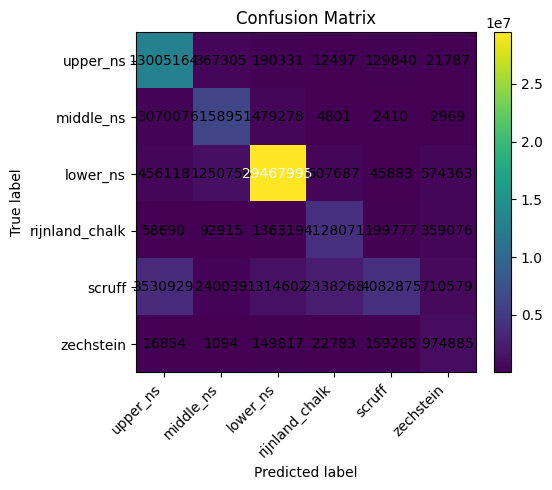

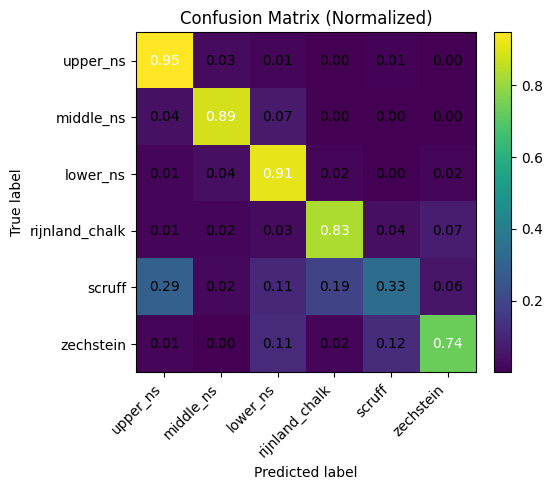

In [ ]:
class_names = ['upper_ns', 'middle_ns', 'lower_ns',
                   'rijnland_chalk', 'scruff', 'zechstein']

cm_50 = scores["confusion_matrix"]
plot_confusion_matrix(cm_50, class_names=class_names, normalize=False)
plot_confusion_matrix(cm_50, class_names=class_names, normalize=True)

In [ ]:
scores_100, cls_iou_100 = evaluate_metrics_diff_ddim(
    model=diff_model,
    data_loader=test_loader,
    device=device,
    n_classes=6,
    steps=100,        # try 50, then 100
    max_batches=None # or 10 for quick debugging
)

print(f"Pixel Acc: {scores_100["Pixel Acc"]}")
print("Class Acc")
for i in range(scores_100["Class Accuracy"].shape[0]):
    print(f"Class {i} Acc: {scores_100["Class Accuracy"][i]}")
print(f"Mean Class Acc: {scores_100["Mean Class Acc"]}")
print(f"Freq Weighted IoU: {scores_100["Freq Weighted IoU"]}")
print(f"Mean IoU: {scores_100["Mean IoU"]}")
print("Per-class IoU:")
for k, v in cls_iou_100.items():
    print(f"Class {k} IoU: {v}")


76it [19:17, 15.24s/it]

Pixel Acc: 0.7701030041117731
Class Acc
Class 0 Acc: 0.9688721231355255
Class 1 Acc: 0.8626592571889302
Class 2 Acc: 0.8453707204718649
Class 3 Acc: 0.7327447994390984
Class 4 Acc: 0.3484486578531478
Class 5 Acc: 0.418112383163813
Mean Class Acc: 0.6960346568753967
Freq Weighted IoU: 0.6465900636631381
Mean IoU: 0.520211864816551
Per-class IoU:
Class 0 IoU: 0.714929191303061
Class 1 IoU: 0.7198207884186687
Class 2 IoU: 0.7792699031152027
Class 3 IoU: 0.4727982639781034
Class 4 IoU: 0.3040440561519245
Class 5 IoU: 0.13040898593234557


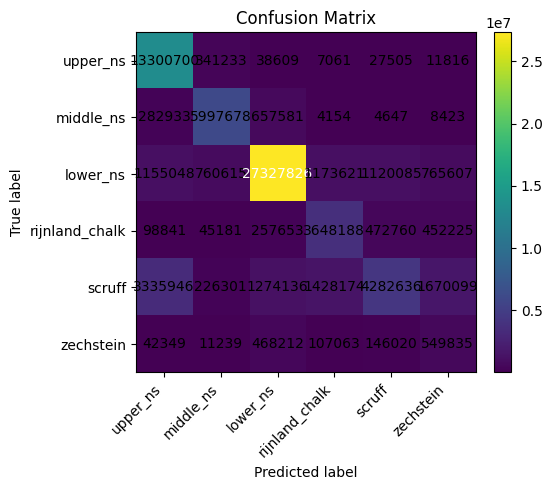

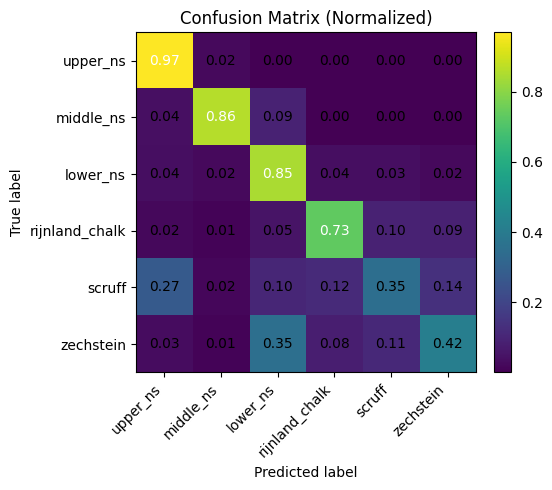

In [ ]:
class_names = ['upper_ns', 'middle_ns', 'lower_ns',
                   'rijnland_chalk', 'scruff', 'zechstein']

cm_100 = scores["confusion_matrix"]
plot_confusion_matrix(cm_100, class_names=class_names, normalize=False)
plot_confusion_matrix(cm_100, class_names=class_names, normalize=True)

In [ ]:
import builtins
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from itertools import islice

@torch.no_grad()
def ddim_step(x, t, t_prev, eps_pred, alphas_bar, fix_batch):
    """
    Deterministic DDIM update (eta=0).
    x:        (B,C,H,W)
    t:        (B,) long
    t_prev:   (B,) long
    eps_pred: (B,C,H,W)
    """
    ab_t = fix_batch(alphas_bar, t, x.device)          # (B,1,1,1)
    ab_prev = fix_batch(alphas_bar, t_prev, x.device)  # (B,1,1,1)

    sqrt_ab_t = torch.sqrt(ab_t)
    sqrt_ab_prev = torch.sqrt(ab_prev)
    sqrt_1mab_t = torch.sqrt(1.0 - ab_t)
    sqrt_1mab_prev = torch.sqrt(1.0 - ab_prev)

    x0_hat = (x - sqrt_1mab_t * eps_pred) / (sqrt_ab_t + 1e-8)
    x_prev = sqrt_ab_prev * x0_hat + sqrt_1mab_prev * eps_pred
    return x_prev


@torch.no_grad()
def sample_ddim(model, cond, steps, n_classes, T, alphas_bar, fix_batch):
    """
    Returns:
      x_final: (B,C,H,W) continuous tensor
      pred:    (B,H,W) integer labels
      conf:    (B,H,W) max softmax probability
    """
    model.eval()
    device = cond.device
    B, _, H, W = cond.shape

    x = torch.randn((B, n_classes, H, W), device=device)

    timesteps = torch.linspace(T - 1, 0, steps, device=device).long()

    for i in range(len(timesteps) - 1):
        t_int = int(timesteps[i].item())
        t_prev_int = int(timesteps[i + 1].item())

        t = torch.full((B,), t_int, device=device, dtype=torch.long)
        t_prev = torch.full((B,), t_prev_int, device=device, dtype=torch.long)

        eps_pred = model(x, t, cond)
        x = ddim_step(x, t, t_prev, eps_pred, alphas_bar, fix_batch)

    probs = torch.softmax(x, dim=1)
    conf = probs.max(dim=1).values
    pred = probs.argmax(dim=1)

    return x, pred, conf


def plot_segmentation_batch_ddim(
    model,
    data_loader,
    device,
    batch_idx=0,
    n_classes=6,
    steps=50,              # DDIM steps (50/100/200)
    n_samples=4,
    cmap_seis="seismic",
    cmap_label="tab20",
    show_confidence=True,
    vmax_seis=None,
    T=1000,
    alphas_bar=None,
    fix_batch=None,
):
    """
    Plots Seismic / Ground Truth / Prediction / Confidence using DDIM sampling.
    """
    assert alphas_bar is not None, "Pass alphas_bar"
    assert fix_batch is not None, "Pass fix_batch"

    model.eval()

    # get the batch at batch_idx
    try:
        batch = next(islice(iter(data_loader), batch_idx, None))
    except StopIteration:
        raise ValueError(f"batch_idx={batch_idx} out of range for data_loader")

    if len(batch) == 2:
        X, y = batch
        direction = None
    else:
        X, y, direction = batch

    if y.ndim == 4:
        y = y.squeeze(1)

    # Keep full batch for plotting, but sampling can be heavy; we’ll sample only first n to save time
    B = X.shape[0]
    n = builtins.min(int(n_samples), int(B))

    cond = X[:n].to(device)          # (n,1,H,W) usually
    y_gpu = y[:n].to(device).long()  # (n,H,W)

    # Run DDIM sampling
    x_final, pred, conf = sample_ddim(
        model=model,
        cond=cond,
        steps=steps,
        n_classes=n_classes,
        T=T,
        alphas_bar=alphas_bar,
        fix_batch=fix_batch,
    )

    # Move to CPU for matplotlib
    X_cpu = X[:n].detach().cpu()
    y_cpu = y[:n].detach().cpu()
    pred_cpu = pred.detach().cpu()
    conf_cpu = conf.detach().cpu()

    ncols = 4 if show_confidence else 3
    fig, axes = plt.subplots(n, ncols, figsize=(4*ncols, 3*n))
    if n == 1:
        axes = [axes]

    for i in range(n):
        x_i = X_cpu[i, 0]     # (H,W)
        y_i = y_cpu[i]        # (H,W)
        p_i = pred_cpu[i]     # (H,W)

        dir_str = ""
        if direction is not None:
            d = direction[i]
            # direction might be a string or tensor; normalize
            if isinstance(d, torch.Tensor):
                d = d.item() if d.numel() == 1 else str(d)
            dir_str = " Inline" if d == "i" else " Cross Line" if d == "x" else f" {d}"

        ax = axes[i][0]
        im0 = ax.imshow(x_i.permute(1, 0), cmap=cmap_seis, aspect="auto", vmax=vmax_seis)
        ax.set_title(f"Seismic{dir_str}")
        ax.axis("off")
        plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[i][1]
        im1 = ax.imshow(y_i.permute(1, 0), cmap=cmap_label, aspect="auto",
                        vmin=0, vmax=n_classes-1, interpolation="nearest")
        ax.set_title(f"Ground Truth{dir_str}")
        ax.axis("off")
        plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

        ax = axes[i][2]
        im2 = ax.imshow(p_i.permute(1, 0), cmap=cmap_label, aspect="auto",
                        vmin=0, vmax=n_classes-1, interpolation="nearest")
        ax.set_title(f"Prediction (DDIM-{steps}){dir_str}")
        ax.axis("off")
        plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

        if show_confidence:
            ax = axes[i][3]
            c_i = conf_cpu[i]  # (H,W)
            im3 = ax.imshow(c_i.permute(1, 0), aspect="auto")
            ax.set_title(f"Confidence{dir_str}")
            ax.axis("off")
            plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


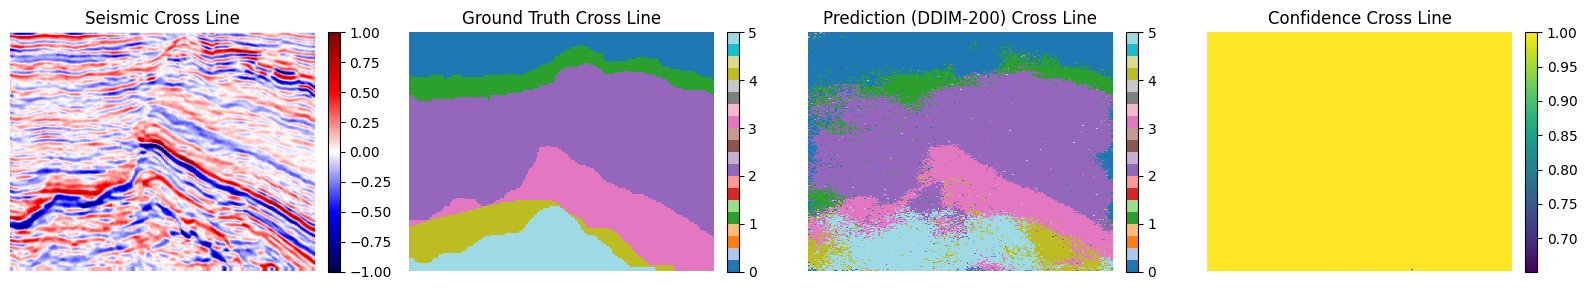

In [ ]:
plot_segmentation_batch_ddim(
    model=diff_model,
    data_loader=test_loader,
    device=device,
    batch_idx=75,
    n_classes=6,
    steps=200,          # try 50 then 100
    n_samples=1,
    T=T,
    alphas_bar=alphas_bar,
    fix_batch=fix_batch,
)


In [ ]:
def plot_sample_by_index_diff(model, dataset, device, idx, n_classes=6, title=""):
    model.eval()

    item = dataset[idx]
    if len(item) == 2:
        X, y = item
        direction = None
    else:
        X, y, direction = item

    #print(y.shape, X.shape)
    X = X.unsqueeze(0).to(device)
    if y.ndim == 3:
        y = y.squeeze(0)
    #print(y.shape, X.shape)
    #print(y.ndim)
    yH, yW = y.shape
    y = y.view(1, yH, yW)
    #print(y.shape, X.shape)
    with torch.no_grad():
        cond = X.to(device)
        y = y.to(device)
        y_onehot = F.one_hot(y, num_classes=6)      # (B,H,W,C)
        y_onehot = y_onehot.permute(0,3,1,2).float() # (B,C,H,W)
        x = torch.randn_like(y_onehot)
        x = x.to(device)

        for t in reversed(range(0,T)):

          # sample z from a normal distribution if condition met
          if t > 0:
              z = torch.randn_like(x)
          else:
              z = 0

          # convert t to a tensor, send to the GPU, and expand its first dimension to be equal to batch size
          t = torch.tensor(t).to(device).expand(x.shape[0])

          # denoise x
          e = model(x, t, cond)

          x = reverse_diffusion(x, t, e, z)

          # if t % 250 == 0:
          #   x = nn.Softmax(dim=1)(x)


        pred = torch.argmax(x, dim=1)
        #pred = torch.argmax(logits, dim=1)[0]

    fig, axs = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(title)
    axs[0].imshow(X[0,0].cpu().permute(1,0), cmap="seismic", aspect="auto")
    axs[0].set_title("Seismic")
    axs[1].imshow(y.permute(2,1,0).detach().cpu(), cmap="tab20", vmin=0, vmax=n_classes-1)
    axs[1].set_title("Ground Truth")
    axs[2].imshow(pred.permute(2, 1,0).detach().cpu(), cmap="tab20", vmin=0, vmax=n_classes-1)
    axs[2].set_title("Prediction")
    for ax in axs:
        ax.axis("off")
    plt.show()


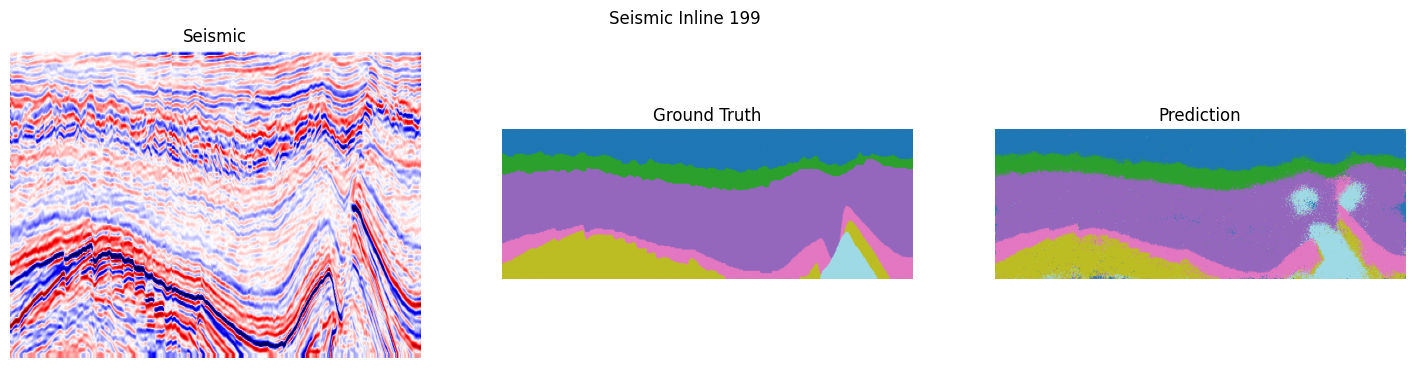

In [ ]:
il_to_plot = 199
tp_to_plot = "Inline"
plot_sample_by_index_diff(diff_model, test_dataset, device, idx=il_to_plot, title=f"Seismic {tp_to_plot} {il_to_plot}")

In [ ]:
@torch.no_grad()
def diffusion_predict_ensemble(
    model,
    cond,                 # (B,1,H,W)
    T,
    n_classes=6,
    K=8,
    noise_cutoff=0,
):
    model.eval()
    device = cond.device
    B, _, H, W = cond.shape

    probs_list = []

    for _ in range(K):
        x = torch.randn(B, n_classes, H, W, device=device)

        for t_int in reversed(range(T)):
            t = torch.full((B,), t_int, device=device, dtype=torch.long)

            eps_pred = model(x, t, cond)

            z = torch.randn_like(x) if t_int > noise_cutoff else torch.zeros_like(x)
            x = reverse_diffusion(x, t, eps_pred, z)

        probs_list.append(F.softmax(x, dim=1))

    probs_mean = torch.mean(torch.stack(probs_list, dim=0), dim=0)
    y_pred = probs_mean.argmax(dim=1)
    conf = probs_mean.max(dim=1).values

    return y_pred, conf, probs_mean

In [ ]:
import builtins
def plot_diffusion_result(
    seismic,    # (B,1,H,W)
    gt,         # (B,H,W)
    pred,       # (B,H,W)
    conf,       # (B,H,W)
    n_classes=6,
    n_samples=2,
    cmap_seis="seismic",
    cmap_label="tab20"
):
    B = seismic.shape[0]
    n = builtins.min(B, n_samples)

    fig, axes = plt.subplots(n, 4, figsize=(16, 3*n))
    if n == 1:
        axes = [axes]

    for i in range(n):
        # Seismic
        ax = axes[i][0]
        im = ax.imshow(seismic[i,0].T, cmap=cmap_seis, aspect="auto")
        ax.set_title("Seismic")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)

        # GT
        ax = axes[i][1]
        im = ax.imshow(gt[i].T, cmap=cmap_label,
                       vmin=0, vmax=n_classes-1, aspect="auto")
        ax.set_title("GT")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)

        # Prediction
        ax = axes[i][2]
        im = ax.imshow(pred[i].T, cmap=cmap_label,
                       vmin=0, vmax=n_classes-1, aspect="auto")
        ax.set_title("Diffusion Ensemble Pred")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)

        # Confidence
        ax = axes[i][3]
        im = ax.imshow(conf[i].T, cmap="viridis", aspect="auto", vmin=0, vmax=1)
        ax.set_title("Confidence")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.tight_layout()
    plt.show()


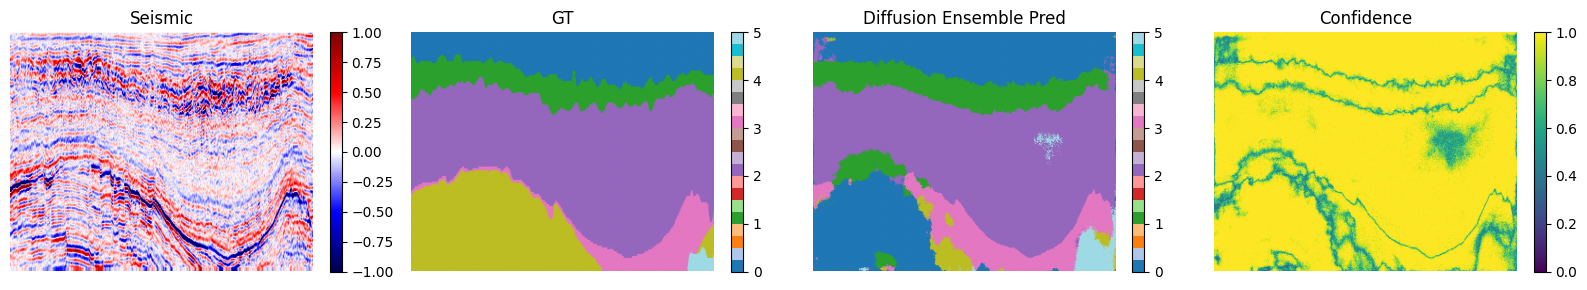

In [ ]:
# get batch
X, y, _ = next(iter(test_loader))

cond = X.to(device)[:1]        # (B,1,H,W)
gt = y.to(device)[:1]          # (B,H,W)

# ensemble prediction
y_pred, conf, _ = diffusion_predict_ensemble(
    model=diff_model,
    cond=cond,
    T=T,
    n_classes=6,
    K=16,
    noise_cutoff=0
)

# plot
plot_diffusion_result(
    seismic=cond.cpu(),
    gt=gt.cpu(),
    pred=y_pred.cpu(),
    conf=conf.cpu(),
    n_classes=6
)
